In [2]:
import numpy as np
from matplotlib import pyplot as plt
import os
from periodicwave.pbc import lattices

In [3]:
import pandas as pd

In [574]:
def convert_moire_scales(me_eff_rel = 0.9, eps_inverse = 0.2, moire_a = 9.8, moire_potential_strength = 10.3):
    """ 
    Converts moire system parameters from SI to natural units used in the code.

    Default values as used in M Geier, K Nazaryan, T Zaklama, and L Fu, Phys. Rev. B 112, 045119

    Arguments:
        me_eff_rel = 0.35             # effective mass in units of bare electron mass
        moire_a = 8.031               # moire lattice constant, nm
        eps_inverse = 0.1             # inverse relative diel. constant of the surrounding dielectric
        moire_potential_strength = 15 # energy scale V of the hexagonal moire potential, meV 

    Returns:
        energy_scale: Conversion factor between energies returned from the code and SI units (meV)
        V: moire potential strength in natural units
        U: interaction energy scale in natural units
    """
    # Natural constants
    a_0  = 5.29177210544e-2      # Bohr radius, nm
    hbar = 6.582119569509066e-1  # meV * ps
    me   = 5.685630060215049e-3  # electron rest mass, meV/[(nm/ps)^2]

    # effective mass in SI units (meV/[(nm/ps)^2])
    me_eff = me_eff_rel * me      # effective mass, meV/[(nm/ps)^2]

    # scales converting dimensionless units from the code to SI units
    # Here we present units where distances are measured in terms of the moire lattice constant moire_a
    # and energies are measured in \hbar^2 / moire_a^2 / me_eff,
    energy_scale = hbar**2 / moire_a**2 / me_eff # meV
    # In these units, the kinetic energy term is
    # - 0.5 \sum_j \nabla_j^2 where j runs over all electrons.
    # In these units, the dimensionless moire potential strength is V, determining
    # - 2 V \sum_i \sum_{n = 1}^{3} \cos ( g_n \cdot r_i + \phi )
    V = moire_potential_strength / energy_scale 
    # The dimensionless Coulomb interaction energy scale is U, determining
    # 0.5 U \sum_{i \neq j} 1/{|r_j - r_i|}
    U = (moire_a / a_0) * eps_inverse * (me_eff / me)

    return energy_scale, V, U

In [5]:
def get_positions_from_latest_npz_files(folder_path, N):
    """
    Loads position data from N latest checkpoints of FermiNet ouput stored in
    a folder with path folder_path
    """
    # Find all files that match the "qmcjax_ckpt_XXXXXX.npz" pattern
    files = [
        f for f in os.listdir(folder_path) 
        if f.startswith("qmcjax_ckpt_") and f.endswith(".npz")
    ]
    
    # Extract the six-digit number from each filename and store it in a tuple (number, filename)
    file_numbers = []
    for file in files:
        try:
            number = int(file.split('_')[-1].split('.')[0])
            file_numbers.append((number, file))
        except ValueError:
            print(f"Skipping file {file}, could not extract valid six-digit number.")

    # Sort the files by the six-digit number in descending order
    sorted_files = sorted(file_numbers, key=lambda x: x[0], reverse=True)

    # Select the top N files with the largest numbers
    largest_files = sorted_files[:N]

    print("In folder " + folder_path + "/ loading checkpoints: ")
    print([el[0] for el in largest_files])

    # Load the contents of the selected files
    positions_ckpt = []
    spins_ckpt = []
    for number, filename in largest_files:
        file_path = os.path.join(folder_path, filename)
        try:
            ckpt_data = np.load(file_path, allow_pickle=True)
            print(list(ckpt_data.keys()))
            data = ckpt_data['data'].item()
            print(list(data.keys()))
            positions_ckpt.append(data['positions'])
            spins_ckpt.append(data['spins'])
            # loaded_data[filename] = data
        except Exception as e:
            print(f"Failed to load {filename}: {e}")

    filenames = [el[1] for el in largest_files]

    return positions_ckpt, spins_ckpt, filenames

In [272]:
def get_positions_from_npz_files(folder_path, N=None, ckpt_range=None, index_range=None,
                                 from_end=True, reverse=True):
    """
    Loads position data from a selected set of FermiNet checkpoints stored in
    a folder with path folder_path.

    N           : number of files to keep (None = keep all that pass the filters)
    ckpt_range  : (lo, hi) inclusive bounds on the checkpoint number; either
                  end may be None, e.g. (200000, None)
    index_range : (i, j) slice on the number-sorted list; negative indices work,
                  e.g. (-20, -10) for the 10 files before the last 10
    from_end    : if N is given, take the N newest (True) or N oldest (False)
    reverse     : return newest first (True) or oldest first (False)
    """
    # Find all files that match the "qmcjax_ckpt_XXXXXX.npz" pattern
    files = [
        f for f in os.listdir(folder_path)
        if f.startswith("qmcjax_ckpt_") and f.endswith(".npz")
    ]

    # Extract the six-digit number from each filename and store it in a tuple (number, filename)
    file_numbers = []
    for file in files:
        try:
            number = int(file.split('_')[-1].split('.')[0])
            file_numbers.append((number, file))
        except ValueError:
            print(f"Skipping file {file}, could not extract valid six-digit number.")

    # Sort the files by the six-digit number in ascending order
    sorted_files = sorted(file_numbers, key=lambda x: x[0])

    # Keep only checkpoints whose number falls inside ckpt_range
    if ckpt_range is not None:
        lo, hi = ckpt_range
        sorted_files = [
            (n, f) for n, f in sorted_files
            if (lo is None or n >= lo) and (hi is None or n <= hi)
        ]

    # Or keep a positional slice of the sorted list
    if index_range is not None:
        i, j = index_range
        sorted_files = sorted_files[i:j]

    # Select N files from whichever end was requested
    if N is not None:
        sorted_files = sorted_files[-N:] if from_end else sorted_files[:N]

    # Order the output
    selected_files = sorted_files[::-1] if reverse else sorted_files

    print("In folder " + folder_path + "/ loading checkpoints: ")
    print([el[0] for el in selected_files])

    # Load the contents of the selected files
    positions_ckpt = []
    spins_ckpt = []
    filenames = []
    for number, filename in selected_files:
        file_path = os.path.join(folder_path, filename)
        try:
            ckpt_data = np.load(file_path, allow_pickle=True)
            print(list(ckpt_data.keys()))
            data = ckpt_data['data'].item()
            print(list(data.keys()))
            positions_ckpt.append(data['positions'])
            spins_ckpt.append(data['spins'])
            filenames.append(filename)
        except Exception as e:
            print(f"Failed to load {filename}: {e}")

    return positions_ckpt, spins_ckpt, filenames

In [872]:
ndim = 2 # spatial dimension of the system
network_type = "CustomPsiformer"

# system parameters
potential_type = "CoulombMoire"
num_unit_cells = 12
nspins = (18, 18)
num_electrons = sum(nspins)
me_eff_rel = 0.9 # in units of bare electron mass
eps_inverse = 0.2 # inverse dielectric constant of surrounding dielectric
moire_lattice_constant_nm = 9.8 # in nm
moire_potential_strength_meV = 10.3 # in meV
moire_potential_phi = 20 # potential shape angle in degrees

In [873]:
# Convert SI units to natural units
energy_scale, moire_potential_strength, interaction_energy_scale = convert_moire_scales(me_eff_rel, eps_inverse, moire_lattice_constant_nm, moire_potential_strength_meV)

In [874]:
print(energy_scale)
print(moire_potential_strength)
print(interaction_energy_scale)

0.881572989311042
11.683661052330509
33.33476886101329


In [875]:
# generate folder name
folder_name = f"el{nspins[0]}_{nspins[1]}_N{num_unit_cells}_V{np.round(moire_potential_strength,8)}_{moire_potential_phi}_U{np.round(interaction_energy_scale,8)}"

In [1046]:
folder_name

'el18_18_N12_V11.68366105_20_U33.33476886'

In [856]:
folder_name = 'el6_6_N4_V11.68366105_20_U33.33476886_0'

In [877]:
moire_a = 1.0
lat_vec, moire_lat_vec, lattice_M = lattices._triangular_lattice_vecs_periodic_potential(a = moire_a, num_sites=num_unit_cells, return_lattice_M = True)
rec = 2 * np.pi * np.linalg.inv(lat_vec)
area = np.abs(np.linalg.det(lat_vec))
r_s = np.sqrt(area / sum(nspins) / np.pi)

In [1127]:
load_N_ckpts = 12 # number of latest checkpoints to load 
batch_size = 2048

In [1128]:
# load configurations from latest checkpoints
positions_ckpt, spins_ckpt, filenames = get_positions_from_latest_npz_files(folder_name2, load_N_ckpts)
#positions_ckpt, spins_ckpt, filenames = get_positions_from_npz_files(folder_name, ckpt_range=(9000, None), N=load_N_ckpts, from_end=False)
shape_pos = np.shape(positions_ckpt)
positions_batch = np.reshape(np.array(positions_ckpt),(shape_pos[0]*shape_pos[1]*shape_pos[2], shape_pos[3]//ndim, ndim))
positions_batch = np.array([lattices.send_positions_to_first_unit_cell(config, lat_vec, rec) for config in positions_batch])


In folder el36_0_N12_V11.68366105_20_U33.33476886/ loading checkpoints: 
[99999, 99411, 97998, 96598, 95182, 93860, 92468, 91074, 89731, 88332, 86927, 85546]
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charges']
['t', 'data', 'params', 'opt_state', 'mcmc_width']
['positions', 'spins', 'atoms', 'charge

In [1010]:
train_data['energy'][99999]*energy_scale

np.float64(-3255.9734683857446)

In [1011]:
train_data['energy'][60000]*energy_scale

np.float64(-3254.3727081517536)

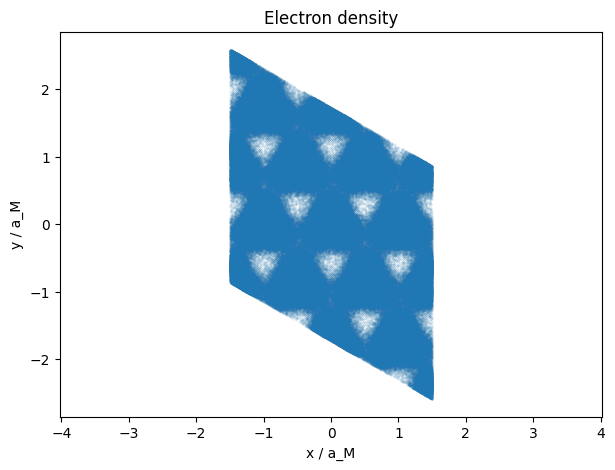

In [1129]:
# plot electron density
fig_n, ax_n = plt.subplots(1, 1, figsize = (7, 5))
positions_plot = np.reshape(np.array(positions_batch),(shape_pos[0]*shape_pos[1]*shape_pos[2]*shape_pos[3]//ndim, ndim))
ax_n.scatter(positions_plot[:,0], positions_plot[:,1], color="tab:blue", s=0.05, alpha=0.2)
ax_n.set_xlabel("x / a_M")
ax_n.set_ylabel("y / a_M")
ax_n.set_title("Electron density")
plt.axis('equal')
plt.show()

In [1130]:
#ndim = 2
#shape_pos = np.shape(positions_ckpt)
nelec = shape_pos[3] // ndim              # 36
n_conf = shape_pos[0] * shape_pos[1] * shape_pos[2]   # 2*4*512 = 4096

positions_batch = np.reshape(np.array(positions_ckpt), (n_conf, nelec, ndim))
positions_batch = np.array([lattices.send_positions_to_first_unit_cell(config, lat_vec, rec)
                            for config in positions_batch])
spins_batch = np.reshape(np.array(spins_ckpt), (n_conf, nelec))

positions_plot = np.reshape(positions_batch, (n_conf * nelec, ndim))
spins_plot     = np.reshape(spins_batch,     (n_conf * nelec,))

print("spin values:", np.unique(spins_plot))
print("fixed spin assignment per electron index?",
      len(np.unique(spins_batch, axis=0)) == 1)

mask_up = spins_plot > 0
mask_dn = ~mask_up
pos_up, pos_dn = positions_plot[mask_up], positions_plot[mask_dn]
print(f"N_up = {mask_up.sum()}, N_dn = {mask_dn.sum()}")

spin values: [1.]
fixed spin assignment per electron index? True
N_up = 884736, N_dn = 0


In [1131]:
a1 = np.array(lat_vec[:,0])
a2 = np.array(lat_vec[:,1])
A = np.stack([a1, a2])              # rows are lattice vectors
Ainv = np.linalg.inv(A)
cell_area = abs(np.linalg.det(A))   # 10.392 = (sqrt(3)/2) * a^2

# Cartesian -> fractional:  r = f1*a1 + f2*a2  =>  f = r @ Ainv
frac_plot = positions_plot @ Ainv
print("fractional range:", frac_plot.min(axis=0), frac_plot.max(axis=0))

fractional range: [-0.5 -0.5] [0.5 0.5]


In [1132]:
nbins = 60                        # ~40 electrons/bin here; see note below
e1 = np.linspace(-0.5, 0.5, nbins + 1)
e2 = np.linspace(-0.5, 0.5, nbins + 1)

f_up = pos_up @ Ainv
f_dn = pos_dn @ Ainv

H_up, _, _ = np.histogram2d(f_up[:, 0], f_up[:, 1], bins=[e1, e2])
H_dn, _, _ = np.histogram2d(f_dn[:, 0], f_dn[:, 1], bins=[e1, e2])

bin_area = cell_area * (e1[1] - e1[0]) * (e2[1] - e2[0])
norm = n_conf * bin_area
n_tot = (H_up + H_dn) / norm
s_z   = (H_up - H_dn) / norm

# fractional bin-edge grid -> Cartesian quad corners
F1, F2 = np.meshgrid(e1, e2, indexing="ij")
X = F1 * a1[0] + F2 * a2[0]
Y = F1 * a1[1] + F2 * a2[1]

print("check normalization:", n_tot.sum() * bin_area, "should be ~", nelec)

check normalization: 36.0 should be ~ 36


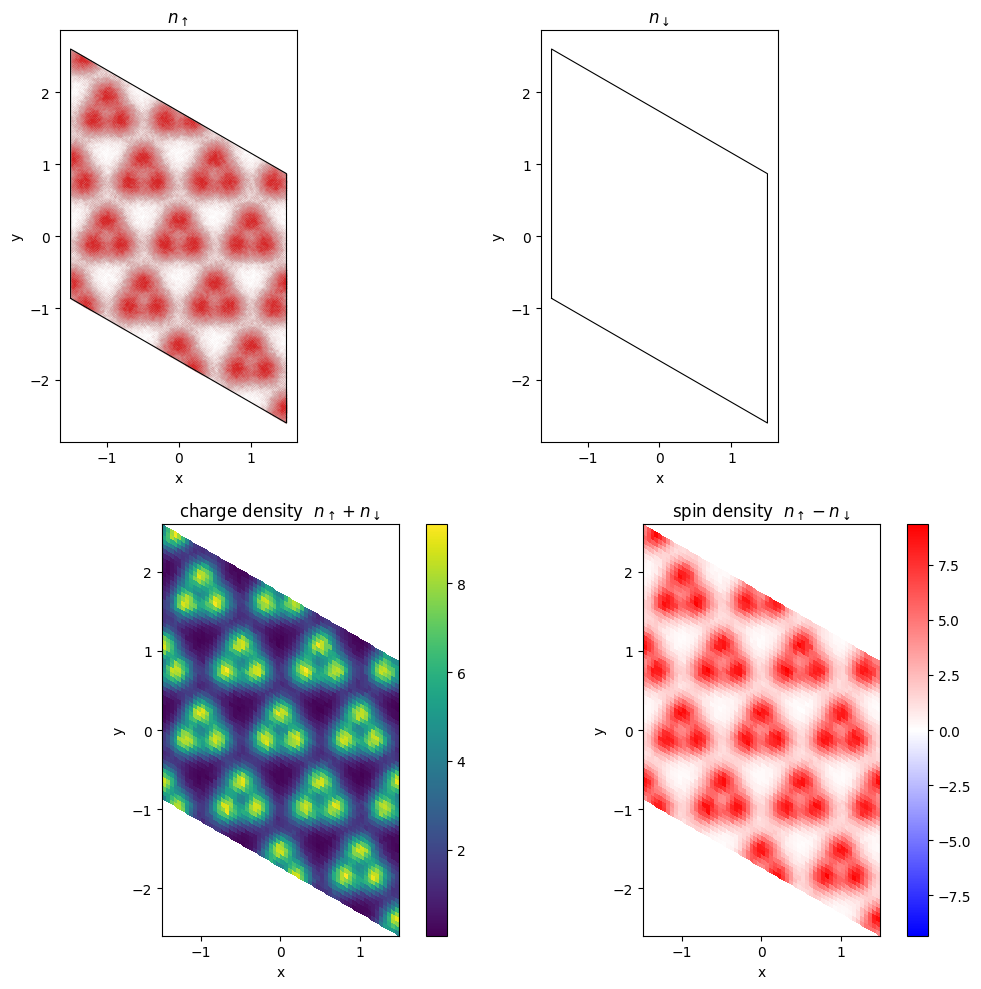

In [1133]:
# unit-cell outline for the scatter panels
corners = np.array([[-.5,-.5],[.5,-.5],[.5,.5],[-.5,.5],[-.5,-.5]]) @ A

fig, axes = plt.subplots(2, 2, figsize=(11, 10))

for ax, pos, c, t in zip(axes[0], [pos_up, pos_dn], ["tab:red", "tab:blue"],
                         [r"$n_\uparrow$", r"$n_\downarrow$"]):
    ax.scatter(pos[:, 0], pos[:, 1], color=c, s=0.0005, alpha=0.2)
    ax.plot(corners[:, 0], corners[:, 1], "k-", lw=0.8)
    ax.set_title(t)

im0 = axes[1, 0].pcolormesh(X, Y, n_tot, cmap="viridis", shading="flat")
axes[1, 0].set_title(r"charge density  $n_\uparrow+n_\downarrow$")
fig.colorbar(im0, ax=axes[1, 0], fraction=0.046)

vmax = np.abs(s_z).max()
im1 = axes[1, 1].pcolormesh(X, Y, s_z, cmap="bwr", vmin=-vmax, vmax=vmax,
                            shading="flat")
axes[1, 1].set_title(r"spin density  $n_\uparrow-n_\downarrow$")
fig.colorbar(im1, ax=axes[1, 1], fraction=0.046)

for ax in axes.ravel():
    ax.set_aspect("equal")
    ax.set_xlabel("x"); ax.set_ylabel("y")

plt.tight_layout()
plt.show()

In [995]:
M = A @ np.linalg.inv(Bmat)
print(np.round(M, 6))        # [[-2, 4], [4, -2]]
print(abs(np.linalg.det(M))) # 12

[[-2.  4.]
 [ 4. -2.]]
12.0


In [1084]:
Mi = np.rint(M).astype(int)
nsite = int(round(abs(np.linalg.det(Mi))))

pq = np.array([[p, q] for p in range(-12, 13) for q in range(-12, 13)])
f = pq @ np.linalg.inv(Mi)
f -= np.floor(f + 0.5 + 1e-9)          # [-0.5, 0.5), boundary -> -0.5
_, idx = np.unique(np.round(f, 6), axis=0, return_index=True)
sites = f[idx] @ A
print("n sites:", len(sites), "expected:", nsite)

n sites: 12 expected: 12


In [1085]:
def site_index(pos, sites, A, Ainv):
    d = pos[:, None, :] - sites[None, :, :]
    df = d @ Ainv
    df -= np.round(df)                  # minimum image
    d = df @ A
    return np.argmin((d**2).sum(-1), axis=1)

site_of = site_index(positions_plot, sites, A, Ainv).reshape(n_conf, nelec)

nsite = len(sites)
sz_conf = np.stack([np.where(site_of == k, spins_batch, 0).sum(1)
                    for k in range(nsite)], axis=1)   # (n_conf, nsite)
n_conf_site = np.stack([(site_of == k).sum(1) for k in range(nsite)], axis=1)

sz   = sz_conf.mean(0)
err  = sz_conf.std(0) / np.sqrt(n_conf)       # optimistic: ignores walker correlation
occ  = n_conf_site.mean(0)

for k in range(nsite):
    print(f"site {k}  r={sites[k].round(2)}  n={occ[k]:.2f}  Sz={sz[k]:+.3f} ± {err[k]:.3f}")
print("sum Sz:", sz.sum())

site 0  r=[-1.5  -0.87]  n=3.00  Sz=-0.918 ± 0.014
site 1  r=[ 0.   -1.73]  n=3.00  Sz=-1.553 ± 0.013
site 2  r=[-0.5  -0.87]  n=3.00  Sz=-1.091 ± 0.014
site 3  r=[ 1.   -1.73]  n=3.00  Sz=+0.297 ± 0.015
site 4  r=[-1.  0.]  n=3.00  Sz=+2.936 ± 0.003
site 5  r=[ 0.5  -0.87]  n=3.00  Sz=-0.878 ± 0.014
site 6  r=[-1.5   0.87]  n=3.00  Sz=-0.609 ± 0.013
site 7  r=[0. 0.]  n=3.00  Sz=-0.430 ± 0.014
site 8  r=[-0.5   0.87]  n=3.00  Sz=+1.204 ± 0.013
site 9  r=[ 1. -0.]  n=3.00  Sz=+2.625 ± 0.007
site 10  r=[-1.    1.73]  n=3.00  Sz=-1.744 ± 0.012
site 11  r=[0.5  0.87]  n=3.00  Sz=+0.162 ± 0.014
sum Sz: 1.937151e-07


In [934]:
for k in range(nsite):
    m = n_conf_site[:, k] == 3
    print(f"site {k}: P(n=3)={m.mean():.3f}  <Sz|n=3>={sz_conf[m,k].mean():+.4f}  "
          f"std={sz_conf[m,k].std():.3f}")

site 0: P(n=3)=0.799  <Sz|n=3>=+2.9692  std=0.246
site 1: P(n=3)=0.800  <Sz|n=3>=+0.9871  std=0.234
site 2: P(n=3)=0.794  <Sz|n=3>=+0.9814  std=0.255
site 3: P(n=3)=0.798  <Sz|n=3>=-2.9610  std=0.276
site 4: P(n=3)=0.801  <Sz|n=3>=-2.9847  std=0.174
site 5: P(n=3)=0.802  <Sz|n=3>=+2.9908  std=0.136
site 6: P(n=3)=0.799  <Sz|n=3>=+2.9591  std=0.283
site 7: P(n=3)=0.791  <Sz|n=3>=-0.9826  std=0.252
site 8: P(n=3)=0.807  <Sz|n=3>=-2.9843  std=0.177
site 9: P(n=3)=0.787  <Sz|n=3>=-0.9680  std=0.281
site 10: P(n=3)=0.799  <Sz|n=3>=-2.9765  std=0.216
site 11: P(n=3)=0.797  <Sz|n=3>=+2.9691  std=0.247


In [935]:
Grec = 2*np.pi*np.linalg.inv(A).T
Brec = 2*np.pi*np.linalg.inv(Bmat).T
qs = np.array([[i,j] for i in range(-6,7) for j in range(-6,7)]) @ Grec
fq = qs @ np.linalg.inv(Brec); fq -= np.floor(fq + 0.5 + 1e-9)
_, idx = np.unique(np.round(fq,6), axis=0, return_index=True)
qs = fq[idx] @ Brec

Sq = np.abs(np.exp(1j * sites @ qs.T).T @ sz)**2 / nsite
o = np.argsort(Sq)[::-1]
for i in o[:4]:
    print(f"q={qs[i].round(3)}  frac={(qs[i] @ np.linalg.inv(Brec)).round(3)}  S(q)={Sq[i]:.2f}")

q=[ 0.   -3.63]  frac=[ 0.  -0.5]  S(q)=29.64
q=[-2.09  3.63]  frac=[-0.33  0.33]  S(q)=7.98
q=[ 2.09 -3.63]  frac=[ 0.33 -0.33]  S(q)=7.98
q=[2.09 0.  ]  frac=[0.33 0.17]  S(q)=6.25


In [936]:
n_ckpt = shape_pos[0]
per_ckpt = n_conf // n_ckpt
sz_ck = sz_conf.reshape(n_ckpt, per_ckpt, nsite).mean(1)   # (n_ckpt, nsite)

print("between-ckpt std per site:", sz_ck.std(0).round(4))
print("within-ckpt SE per site:  ", (sz_conf.std(0)/np.sqrt(per_ckpt)).round(4))
np.set_printoptions(precision=2, suppress=True)
print(sz_ck)

between-ckpt std per site: [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.02 0.01 0.01 0.01 0.01]
within-ckpt SE per site:   [0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01 0.01]
[[ 2.83  0.97  0.9  -2.78 -2.93  2.96  2.79 -0.92 -2.91 -0.88 -2.88  2.84]
 [ 2.84  0.94  0.9  -2.78 -2.92  2.94  2.79 -0.92 -2.92 -0.83 -2.89  2.84]
 [ 2.82  0.94  0.93 -2.79 -2.9   2.95  2.8  -0.94 -2.93 -0.86 -2.88  2.86]
 [ 2.84  0.93  0.93 -2.8  -2.92  2.95  2.79 -0.91 -2.92 -0.86 -2.87  2.83]
 [ 2.84  0.93  0.92 -2.79 -2.9   2.95  2.8  -0.94 -2.93 -0.86 -2.88  2.85]
 [ 2.84  0.96  0.9  -2.8  -2.93  2.96  2.79 -0.9  -2.93 -0.85 -2.88  2.83]
 [ 2.83  0.92  0.94 -2.79 -2.93  2.96  2.81 -0.94 -2.92 -0.87 -2.87  2.86]
 [ 2.85  0.94  0.93 -2.79 -2.92  2.97  2.82 -0.93 -2.92 -0.87 -2.9   2.83]
 [ 2.85  0.93  0.93 -2.81 -2.91  2.93  2.81 -0.91 -2.92 -0.86 -2.85  2.82]
 [ 2.83  0.93  0.92 -2.8  -2.93  2.96  2.82 -0.94 -2.91 -0.84 -2.87  2.82]
 [ 2.86  0.95  0.92 -2.79 -2.9   2.93  2.78 -0.95 -2.91 -0.84 -2.88  2.8

In [767]:
np.max(rho)

np.float64(9.776614909910263)

In [1114]:
#Lattice vectors
a1 = np.array(lat_vec[:,0])
a2 = np.array(lat_vec[:,1])

In [1115]:
# Primitive reciprocal lattice vectors
b1 = (2 * np.pi / area) * np.array([a2[1], -a2[0]])
b2 = (2 * np.pi / area) * np.array([-a1[1], a1[0]])

In [1116]:
# --- 3. Convert Cartesian to Fractional Coordinates ---
# Matrix inverse approach: s = R^(-1) * r
lat_vec_inv = np.linalg.inv(lat_vec)
# Vectorized multiplication for all positions
fractional_positions = positions_plot @ lat_vec_inv.T
# Enforce periodic boundaries just in case any drifted out
#fractional_positions = positions_plot % 1.0

In [1117]:
# --- 4. Setup Fourier Grid and Cutoff ---
# Choose grid size for FFT (must be large enough to hold G_max)
# N_grid x N_grid defines the maximum frequencies tracked
N_grid = 128  
G_max = np.linalg.norm(8*b1)  # Cutoff radius for smoothing. Lower = smoother, Higher = sharper.

# Create structure factor grid
rho_G = np.zeros((N_grid, N_grid), dtype=complex)

# Generate frequencies mapping to standard FFT layout
# (0 to N/2, then -N/2 to -1)
n1_range = np.fft.fftfreq(N_grid, d=1/N_grid) 
n2_range = np.fft.fftfreq(N_grid, d=1/N_grid) 

s1 = fractional_positions[:, 0]
s2 = fractional_positions[:, 1]

In [1118]:
# --- 5. Accumulate rho(G) ---
# Loop over the grid indices
for i, n1 in enumerate(n1_range):
    for j, n2 in enumerate(n2_range):
        # Calculate actual G-vector to check the physical circular cutoff
        G_vec = n1 * b1 + n2 * b2
        G_norm = np.linalg.norm(G_vec)
        
        if G_norm <= G_max:
            # G . r = 2 * pi * (n1*s1 + n2*s2)
            phases = 2 * np.pi * (n1 * s1 + n2 * s2)
            # Average over batches (divide by N_batch, not total_points, so rho(G=0) = Ne)
            rho_G[i, j] = np.sum(np.exp(-1j * phases)) / (batch_size*load_N_ckpts)

In [1119]:
# --- 6. Inverse FFT back to Real Space ---
# ifft2 expects the layout we set up. 
# Multiplying by (N_grid^2 / A) handles the proper continuous density scaling
rho_real_fractional = np.fft.ifft2(rho_G) * (N_grid**2 / area)
rho_real = np.real(rho_real_fractional) # Drop microscopic imaginary noise

# --- 7. Plotting the Parallelogram Density ---
# Generate a uniform grid in fractional space
s1_g, s2_g = np.meshgrid(np.linspace(0, 1, N_grid), np.linspace(0, 1, N_grid), indexing='ij')

# Transform the uniform evaluation grid back to Cartesian coordinates for plotting
X_grid = s1_g * a1[0] + s2_g * a2[0]
Y_grid = s1_g * a1[1] + s2_g * a2[1]

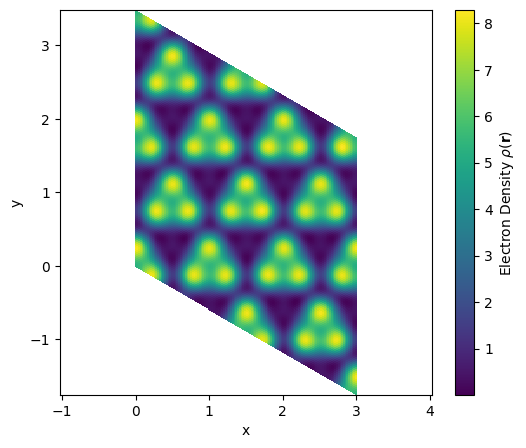

In [1120]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_grid, Y_grid, rho_real, shading='auto', cmap='viridis') 
plt.colorbar(label='Electron Density $\\rho(\\mathbf{r})$')
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
#plt.scatter(X_grid[3, 0]+0.5,Y_grid[3, 0]+np.sqrt(3)/2, color = 'red')
#plt.scatter(0.5,np.sqrt(3)/2)
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
#plt.savefig("phi20_aM98nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

In [975]:
shape_spins = np.shape(spins_ckpt)
# Flattens (30, 2, 512, 12) -> (30720, 12)
spins_batch = np.reshape(np.array(spins_ckpt), (shape_spins[0] * shape_spins[1] * shape_spins[2], num_electrons))

In [976]:
# Create boolean masks based on the spin values
spin_up_mask = (spins_batch == 1.)
spin_down_mask = (spins_batch == -1.)

# Apply the masks to your unit-cell corrected positions
# This automatically flattens the arrays to (N_up_total, 2) and (N_down_total, 2)
positions_up = positions_batch[spin_up_mask]
positions_down = positions_batch[spin_down_mask]

In [977]:
fractional_positions_up = positions_up @ lat_vec_inv.T
fractional_positions_down = positions_down @ lat_vec_inv.T

In [978]:
# Create structure factor grid
rho_G_up = np.zeros((N_grid, N_grid), dtype=complex)
rho_G_down = np.zeros((N_grid, N_grid), dtype=complex)
# Generate frequencies mapping to standard FFT layout
# (0 to N/2, then -N/2 to -1)
#n1_range = np.fft.fftfreq(N_grid, d=1/N_grid) 
#n2_range = np.fft.fftfreq(N_grid, d=1/N_grid) 

s1_up = fractional_positions_up[:, 0]
s2_up = fractional_positions_up[:, 1]
s1_down = fractional_positions_down[:, 0]
s2_down = fractional_positions_down[:, 1]

In [979]:
# --- 5. Accumulate rho(G) ---
# Loop over the grid indices
for i, n1 in enumerate(n1_range):
    for j, n2 in enumerate(n2_range):
        # Calculate actual G-vector to check the physical circular cutoff
        G_vec = n1 * b1 + n2 * b2
        G_norm = np.linalg.norm(G_vec)
        
        if G_norm <= G_max:
            # G . r = 2 * pi * (n1*s1 + n2*s2)
            phases_up = 2 * np.pi * (n1 * s1_up + n2 * s2_up)
            phases_down = 2 * np.pi * (n1 * s1_down + n2 * s2_down)
            # Average over batches (divide by N_batch, not total_points, so rho(G=0) = Ne)
            rho_G_up[i, j] = np.sum(np.exp(-1j * phases_up)) / (batch_size*load_N_ckpts)
            rho_G_down[i, j] = np.sum(np.exp(-1j * phases_down)) / (batch_size*load_N_ckpts)

In [980]:
# --- 6. Inverse FFT back to Real Space ---
# ifft2 expects the layout we set up. 
# Multiplying by (N_grid^2 / A) handles the proper continuous density scaling
rho_real_fractional_up = np.fft.ifft2(rho_G_up) * (N_grid**2 / area)
rho_real_up = np.real(rho_real_fractional_up) # Drop microscopic imaginary noise

# --- 7. Plotting the Parallelogram Density ---
# Generate a uniform grid in fractional space
s1_g_up, s2_g_up = np.meshgrid(np.linspace(0, 1, N_grid), np.linspace(0, 1, N_grid), indexing='ij')

# Transform the uniform evaluation grid back to Cartesian coordinates for plotting
X_grid_up = s1_g_up * a1[0] + s2_g_up * a2[0]
Y_grid_up = s1_g_up * a1[1] + s2_g_up * a2[1]

rho_real_fractional_down = np.fft.ifft2(rho_G_down) * (N_grid**2 / area)
rho_real_down = np.real(rho_real_fractional_down) # Drop microscopic imaginary noise

# --- 7. Plotting the Parallelogram Density ---
# Generate a uniform grid in fractional space
s1_g_down, s2_g_down = np.meshgrid(np.linspace(0, 1, N_grid), np.linspace(0, 1, N_grid), indexing='ij')

# Transform the uniform evaluation grid back to Cartesian coordinates for plotting
X_grid_down = s1_g_down * a1[0] + s2_g_down * a2[0]
Y_grid_down = s1_g_down * a1[1] + s2_g_down * a2[1]

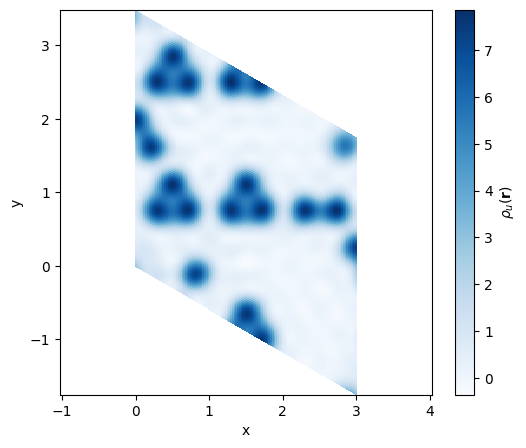

In [981]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_grid_up, Y_grid_up, rho_real_up, shading='auto', cmap='Blues')
plt.colorbar(label='$\\rho_u(\\mathbf{r})$')
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
#plt.savefig("phi45_aM10nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

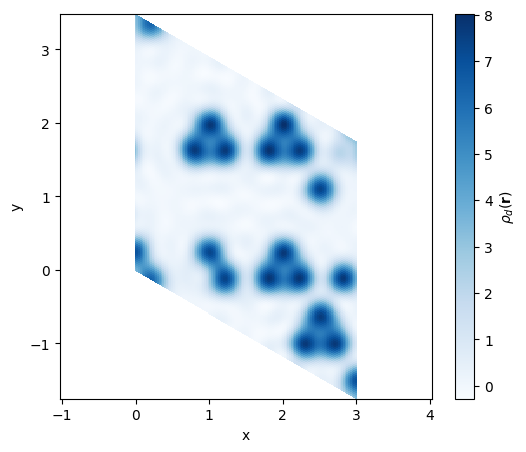

In [982]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.pcolormesh(X_grid_down, Y_grid_down, rho_real_down, shading='auto', cmap='Blues')
plt.colorbar(label='$\\rho_d(\\mathbf{r})$')
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
#plt.savefig("phi45_aM10nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

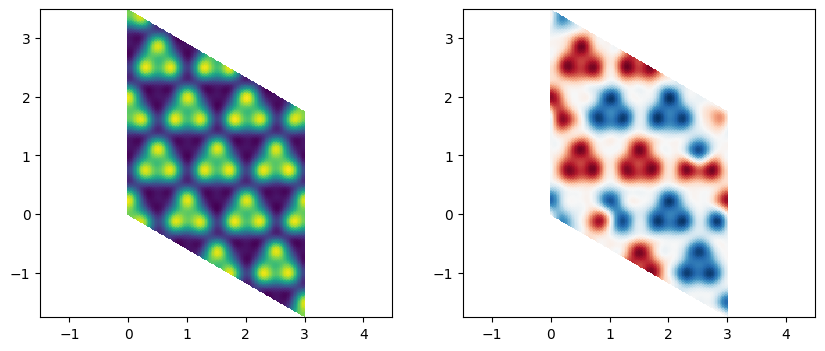

In [983]:
# The physical spin density map
spin_density = (rho_real_up - rho_real_down)

# Plotting
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
# A diverging colormap (like RdBu) is best for spin density so zero is white, up is red, down is blue
ax1.pcolormesh(X_grid, Y_grid, rho_real, shading='auto', cmap='viridis')
ax2.pcolormesh(X_grid, Y_grid, spin_density, shading='auto', cmap='RdBu_r', vmin=-np.max(np.abs(spin_density)), vmax=np.max(np.abs(spin_density)))

#ax2.colorbar(label='Spin Density $s(\\mathbf{r})$')
#plt.title('Smooth Spin Density')
ax1.axis('equal')
ax2.axis('equal')
#plt.savefig("phi20_aM98nm_spin_den_Sz0.png", dpi=150, bbox_inches="tight")
plt.show()

In [88]:


#n_repeat = 1   # 1 -> 3x3 tiling, 2 -> 5x5 tiling, etc.
#vmin, vmax = rho_real.min(), rho_real.max()

#mesh = None
#for i in range(-n_repeat, n_repeat + 1):
    #for j in range(-n_repeat, n_repeat + 1):
      #  shift = i * a1 + j * a2
     #   m = ax.pcolormesh(X_grid + shift[0], Y_grid + shift[1], rho_real,
    #                       shading='auto', cmap='Blues',
   #                        vmin=vmin, vmax=vmax)
  #      if mesh is None:
 #           mesh = m  # keep one handle for the colorbar            

# outline only the elementary (unit) cell
#from matplotlib.patches import Polygon
#outline = Polygon(base_corners, closed=True, fill=False,
 #                  edgecolor='red', linewidth=1, zorder=10)
#ax.add_patch(outline)

#ax.set_aspect('equal')
#ax.set_xlim(-1.4, 2.5)
#ax.set_ylim(-1, 2.5)
#fig.colorbar(mesh, ax=ax, label='rho')
#plt.show()

In [87]:
l = np.linalg.norm(a1)

In [687]:
np.min(spin_density)

np.float64(-7.977300977034246)

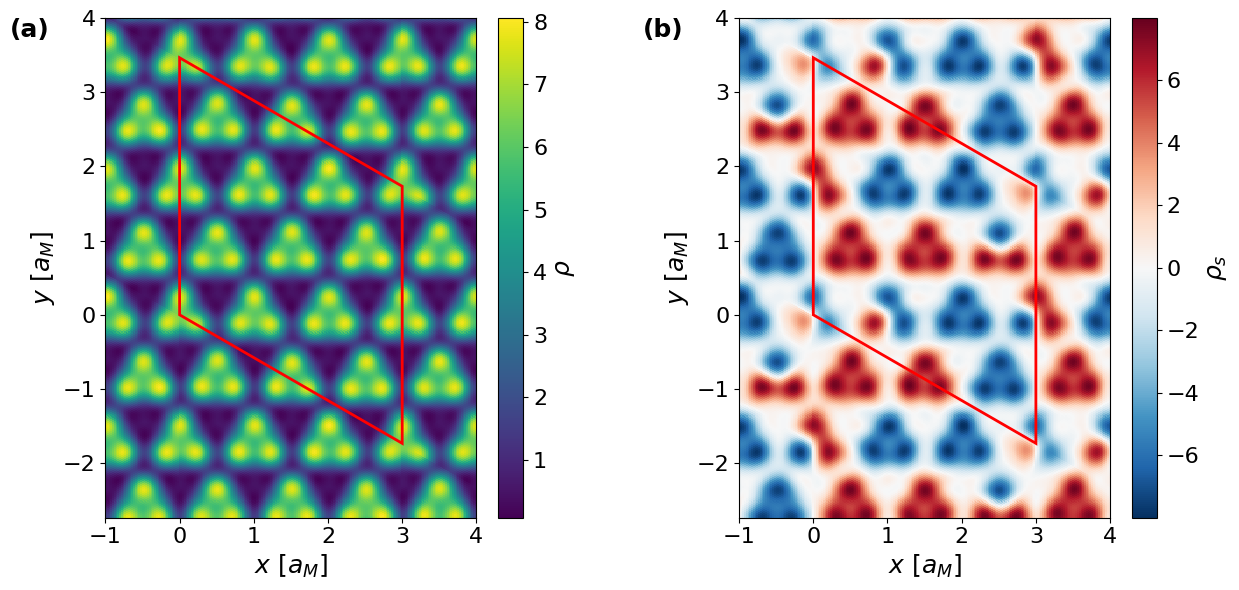

In [986]:
from matplotlib.patches import Polygon

#a1 = np.array([2.0, 0.0])
#a2 = np.array([-1.0, np.sqrt(3)])

base_corners = np.array([
    [0, 0],
    a1,
    a1 + a2,
    a2
])
cw = 1.0
def plot_periodic(ax, X_grid, Y_grid, data, cmap, n_repeat=2,
                   xlim=(-cw+np.min([a1[0],a2[0]]), cw+np.max([a1[0],a2[0]])), ylim=(-cw+np.min([a1[1],a2[1]]), cw+np.max([a1[0],a2[0]])), title=None, label_fontsize=14, tick_fontsize=12,panel_label=None, panel_label_fontsize=18):
    data_min, data_max = data.min(), data.max()

    if data_min < -3 and data_max > 0:
        # diverging data: symmetric limits centered at zero
        vabs = max(abs(data_min), abs(data_max))
        vmin, vmax = -vabs, vabs
    else:
        # single-signed data: use actual range
        vmin, vmax = data_min, data_max
    mesh = None
    for i in range(-n_repeat, n_repeat + 1):
        for j in range(-n_repeat, n_repeat + 1):
            shift = i * a1 + j * a2
            m = ax.pcolormesh(X_grid + shift[0], Y_grid + shift[1], data,
                               shading='auto', cmap=cmap,
                               vmin=vmin, vmax=vmax, rasterized=True)
            if mesh is None:
                mesh = m

    outline = Polygon(base_corners, closed=True, fill=False,
                       edgecolor='red', linewidth=2, zorder=10)
    ax.add_patch(outline)

    ax.set_aspect('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r'$x$ [$a_M$]', fontsize=label_fontsize)
    ax.set_ylabel(r'$y$ [$a_M$]', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if title:
        ax.set_title(title)
    if panel_label:
        ax.text(-0.15, 1.0, panel_label, transform=ax.transAxes,
         fontsize=panel_label_fontsize, fontweight='bold',
         va='top', ha='right')    
    return mesh

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
label_fontsize = 18
tick_fontsize = 16
cbar_label_fontsize = 18
cbar_tick_fontsize = 16

mesh1 = plot_periodic(axes[0], X_grid, Y_grid, rho_real, cmap='viridis',
                       title=None,
                       label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,panel_label='(a)')
mesh2 = plot_periodic(axes[1], X_grid, Y_grid, spin_density, cmap='RdBu_r',
                       title=None,
                       label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,panel_label='(b)')

cbar1 = fig.colorbar(mesh1, ax=axes[0], label=r'$\rho$', fraction=0.046, pad=0.04)
cbar1.set_label(r'$\rho$', fontsize=cbar_label_fontsize)
cbar1.ax.tick_params(labelsize=cbar_tick_fontsize)

cbar2 = fig.colorbar(mesh2, ax=axes[1], label=r'$\rho_s$', fraction=0.046, pad=0.04)
cbar2.set_label(r'$\rho_s$', fontsize=cbar_label_fontsize)
cbar2.ax.tick_params(labelsize=cbar_tick_fontsize)

plt.tight_layout()
plt.savefig("charge_spin_36.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [745]:
np.max(rho_real)

np.float64(7.970656055836662)

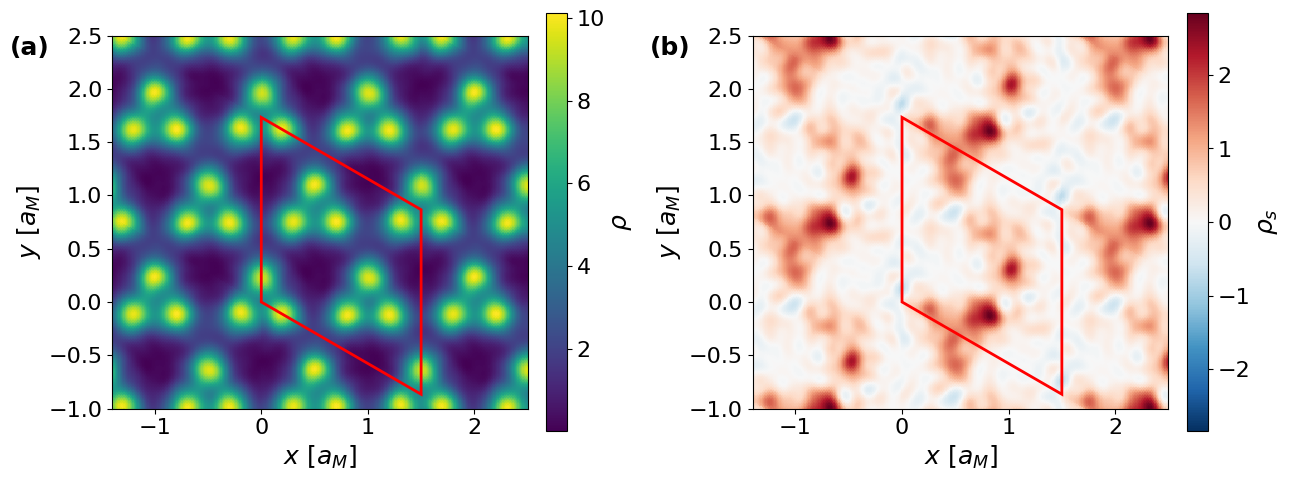

In [526]:
from matplotlib.patches import Polygon

#a1 = np.array([2.0, 0.0])
#a2 = np.array([-1.0, np.sqrt(3)])

base_corners = np.array([
    [0, 0],
    a1,
    a1 + a2,
    a2
])

def plot_periodic(ax, X_grid, Y_grid, data, cmap, n_repeat=2,
                   xlim=(-1.4, 2.5), ylim=(-1, 2.5), title=None, label_fontsize=14, tick_fontsize=12,panel_label=None, panel_label_fontsize=18):
    data_min, data_max = data.min(), data.max()

    if data_min < -0.1 and data_max > 0:
        # diverging data: symmetric limits centered at zero
        vabs = max(abs(data_min), abs(data_max))
        vmin, vmax = -vabs, vabs
    else:
        # single-signed data: use actual range
        vmin, vmax = data_min, data_max
    mesh = None
    for i in range(-n_repeat, n_repeat + 1):
        for j in range(-n_repeat, n_repeat + 1):
            shift = i * a1 + j * a2
            m = ax.pcolormesh(X_grid + shift[0], Y_grid + shift[1], data,
                               shading='auto', cmap=cmap,
                               vmin=vmin, vmax=vmax, rasterized=True)
            if mesh is None:
                mesh = m

    outline = Polygon(base_corners, closed=True, fill=False,
                       edgecolor='red', linewidth=2, zorder=10)
    ax.add_patch(outline)

    ax.set_aspect('equal')
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r'$x$ [$a_M$]', fontsize=label_fontsize)
    ax.set_ylabel(r'$y$ [$a_M$]', fontsize=label_fontsize)
    ax.tick_params(axis='both', labelsize=tick_fontsize)
    if title:
        ax.set_title(title)
    if panel_label:
        ax.text(-0.15, 1.0, panel_label, transform=ax.transAxes,
         fontsize=panel_label_fontsize, fontweight='bold',
         va='top', ha='right')    
    return mesh

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
label_fontsize = 18
tick_fontsize = 16
cbar_label_fontsize = 18
cbar_tick_fontsize = 16

mesh1 = plot_periodic(axes[0], X_grid, Y_grid, rho_real, cmap='viridis',
                       title=None,
                       label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,panel_label='(a)')
mesh2 = plot_periodic(axes[1], X_grid, Y_grid, spin_density, cmap='RdBu_r',
                       title=None,
                       label_fontsize=label_fontsize, tick_fontsize=tick_fontsize,panel_label='(b)')

cbar1 = fig.colorbar(mesh1, ax=axes[0], label=r'$\rho$', fraction=0.046, pad=0.04)
cbar1.set_label(r'$\rho$', fontsize=cbar_label_fontsize)
cbar1.ax.tick_params(labelsize=cbar_tick_fontsize)

cbar2 = fig.colorbar(mesh2, ax=axes[1], label=r'$\rho_s$', fraction=0.046, pad=0.04)
cbar2.set_label(r'$\rho_s$', fontsize=cbar_label_fontsize)
cbar2.ax.tick_params(labelsize=cbar_tick_fontsize)

plt.tight_layout()
#plt.savefig("v1.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [481]:
rho_real.max()

np.float64(8.08048451505018)

In [524]:
np.min(spin_density)

np.float64(-0.7538457670866459)

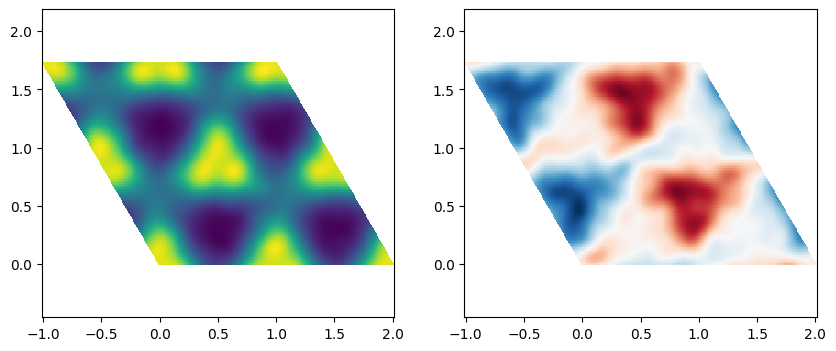

In [61]:
# The physical spin density map
spin_density = (rho_real_up - rho_real_down)

# Plotting
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
# A diverging colormap (like RdBu) is best for spin density so zero is white, up is red, down is blue
ax1.pcolormesh(X_grid, Y_grid, rho_real, shading='auto', cmap='viridis')
ax2.pcolormesh(X_grid, Y_grid, spin_density, shading='auto', cmap='RdBu_r', vmin=-np.max(np.abs(spin_density)), vmax=np.max(np.abs(spin_density)))

#ax2.colorbar(label='Spin Density $s(\\mathbf{r})$')
#plt.title('Smooth Spin Density')
ax1.axis('equal')
ax2.axis('equal')
#plt.savefig("phi20_aM98nm_spin_den_Sz0.png", dpi=150, bbox_inches="tight")
plt.show()

In [868]:
np.max(spin_density)

np.float64(0.46882552434008584)

In [139]:
def load_csv_data(folder_path, file_name):
    # Construct the full path to the CSV file
    file_path = os.path.join(folder_path, file_name)
    
    # Load the CSV file, only reading the first 5 columns
    data = pd.read_csv(file_path, usecols=["step", "energy", "ewmean", "ewvar", "pmove"])
    
    return data

In [205]:
import re

In [746]:
def load_csv_data(folder_path, file_name, combine=True):
    # Split "train_stats.csv" -> ("train_stats", ".csv")
    stem, suffix = os.path.splitext(file_name)
    COLS = ["step", "energy", "ewmean", "ewvar", "pmove"]
    if not combine:
        return pd.read_csv(os.path.join(folder_path, file_name), usecols=COLS)

    pattern = re.compile(r"^" + re.escape(stem) + r"(?:_(\d+))?" + re.escape(suffix) + r"$")

    found = []
    for name in os.listdir(folder_path):
        m = pattern.match(name)
        if m:
            # bare name is the newest; higher _N is older
            idx = int(m.group(1)) if m.group(1) else -1
            found.append((idx, name))

    if not found:
        raise FileNotFoundError("No files matching %s[_N]%s in %s" % (stem, suffix, folder_path))

    found.sort(key=lambda t: -t[0])  # oldest -> newest

    frames = [pd.read_csv(os.path.join(folder_path, name), usecols=COLS)
              for _, name in found]

    data = pd.concat(frames, ignore_index=True)
    data = data.sort_values("step", kind="mergesort")        # stable sort
    data = data.drop_duplicates(subset="step", keep="last")  # newer file wins

    return data.reset_index(drop=True)

In [162]:
def load_csv_inference(folder_path, file_name):
    # Construct the full path to the CSV file
    file_path = os.path.join(folder_path, file_name)
    
    # Load the CSV file, only reading the first 5 columns
    data = pd.read_csv(file_path, usecols=["step", "energy", "ewmean", "ewvar", "pmove", "s2_mean", "s2_var"])
    
    return data

In [208]:
train_data

,step,energy,ewmean,ewvar,pmove
0,0,-1932.5562,-1932.5562,-0.000000,0.082194
1,1,-1933.2385,-1932.6244,0.041907,0.113314
2,2,-1926.6023,-1932.0222,3.301623,0.114421
3,3,-1944.5259,-1933.2726,17.042202,0.114453
4,4,-1936.3296,-1933.5782,16.179056,0.111816
...,...,...,...,...,...
76286,76286,NaN,NaN,NaN,0.000000
76287,76287,NaN,NaN,NaN,0.000000
76288,76288,NaN,NaN,NaN,0.000000
76289,76289,NaN,NaN,NaN,0.000000


In [1042]:
train_data = load_csv_data(folder_name, "train_stats.csv", combine=False)

In [516]:
train_data2 = load_csv_data(folder_name, "train_stats.csv")

In [163]:
inference_data = load_csv_inference(folder_name, "inference_stats.csv")

In [169]:
inference_data2 = load_csv_inference(folder_name2, "inference_stats.csv")

In [372]:
np.min(inference_data2['s2_mean'])

np.float64(-170.36304)

In [323]:
clean_arr = inference_data['s2_mean'][0:][~np.isnan(inference_data['s2_mean'][0:])]

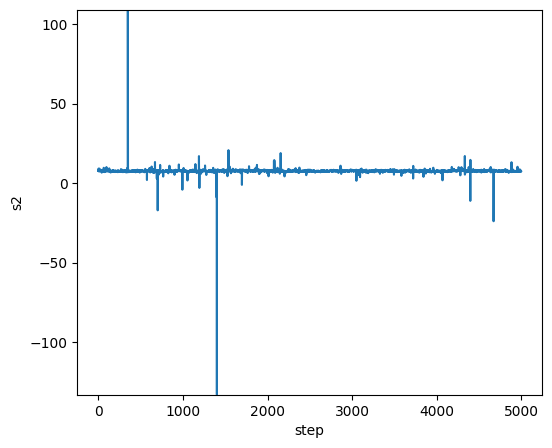

In [324]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.plot(range(len(clean_arr)), clean_arr)
plt.ylim(np.min(clean_arr), np.max(clean_arr))
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
plt.xlabel('step')
plt.ylabel('s2')
#plt.axis('equal')
#plt.savefig("phi45_aM10nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

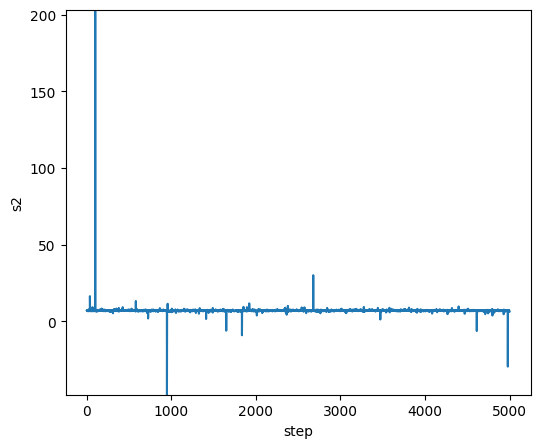

In [165]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.plot(range(len(inference_data['s2_mean'])), inference_data['s2_mean'])
plt.ylim(np.min(inference_data['s2_mean']), np.max(inference_data['s2_mean']))
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
plt.xlabel('step')
plt.ylabel('s2')
#plt.axis('equal')
#plt.savefig("phi45_aM10nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

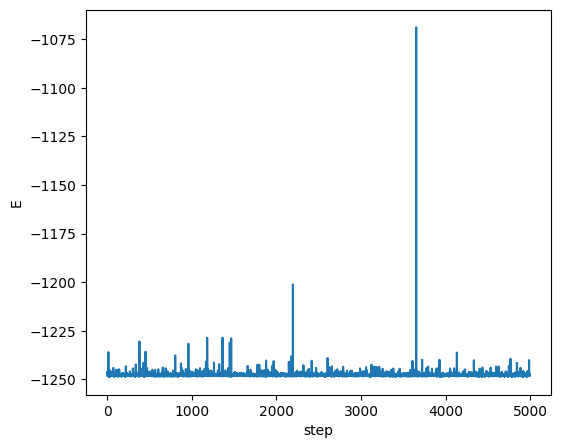

In [307]:
# Use pcolormesh because it handles non-orthogonal, warped grids perfectly
plt.figure(figsize=(6, 5))
plt.plot(inference_data['step'], inference_data['energy'])
#plt.ylim(np.min(clean_arr), np.max(clean_arr))
#plt.title('Smooth Electron Density (Reciprocal Space Filtered)')
plt.xlabel('step')
plt.ylabel('E')
#plt.axis('equal')
#plt.savefig("phi45_aM10nm_Sz0_den.png", dpi=150, bbox_inches="tight")
plt.show()

In [174]:
inference_data['energy'].mean()

np.float64(-1247.9575388399999)

In [175]:
inference_data2['energy'].mean()

np.float64(-1247.72747862)

In [179]:
np.std(inference_data2['energy']) / np.sqrt(len(inference_data2['energy']))

np.float64(0.015411491046676143)

In [180]:
def blocking_analysis(data, min_blocks=16):
    """
    Blocking analysis for correlated Monte Carlo data.

    Parameters
    ----------
    data : array_like
        1D array of Monte Carlo measurements.
    min_blocks : int
        Stop blocking when fewer than this many blocks remain.

    Returns
    -------
    results : dict
        {
            "mean": sample mean,
            "stderr": best estimate of standard error,
            "block_sizes": array of block sizes,
            "errors": array of estimated errors,
        }
    """
    data = np.asarray(data)
    N = len(data)

    mean = np.mean(data)

    block_sizes = []
    errors = []

    block_size = 1

    while N // block_size >= min_blocks:
        n_blocks = N // block_size

        # truncate so all blocks have equal size
        trimmed = data[:n_blocks * block_size]

        blocks = trimmed.reshape(n_blocks, block_size)
        block_means = np.mean(blocks, axis=1)

        error = np.std(block_means, ddof=1) / np.sqrt(n_blocks)

        block_sizes.append(block_size)
        errors.append(error)

        block_size *= 2

    return {
        "mean": mean,
        "stderr": errors[-1],      # largest block size
        "block_sizes": np.array(block_sizes),
        "errors": np.array(errors),
    }

In [195]:
res = blocking_analysis(inference_data['energy'])

print(f"Mean     = {res['mean']:.6f}")
print(f"Std error= {res['stderr']:.6f}")

Mean     = -1247.957539
Std error= 0.009672


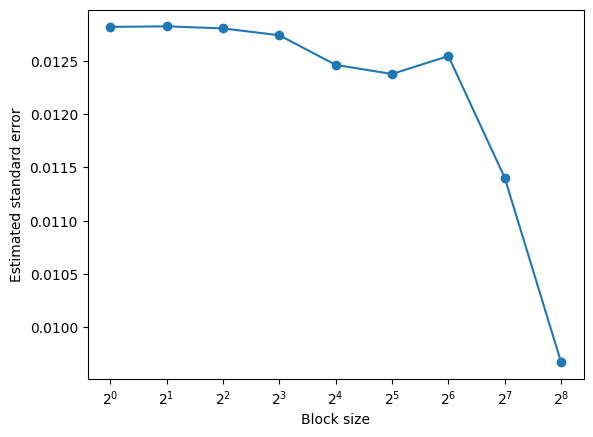

In [196]:
plt.plot(res["block_sizes"], res["errors"], "o-")
plt.xscale("log", base=2)
plt.xlabel("Block size")
plt.ylabel("Estimated standard error")
plt.show()

In [197]:
res["errors"]

array([0.01281736, 0.01282264, 0.01280303, 0.01273889, 0.01246133,
       0.01237551, 0.0125438 , 0.01140191, 0.00967215])

In [166]:
s2_data = inference_data['s2_mean'].dropna()

In [170]:
s2_data2 = inference_data2['s2_mean'].dropna()

In [168]:
s2_data.mean()

np.float64(7.0161702979800005)

In [171]:
s2_data2.mean()

np.float64(7.6328689487)

In [177]:
np.std(s2_data2) / np.sqrt(len(s2_data2))

np.float64(0.03712217161736017)

In [330]:
s2_data.median()

np.float64(7.6348552)

In [329]:
s2_final_value = s2_data.mean()
s2_final_value

np.float64(7.6328689487)

In [337]:
(-1.0+np.sqrt(1+4*s2_final_value))/2.0

np.float64(2.307644733348577)

In [173]:
s2_std_dev = s2_data.std(ddof=1)
s2_error = s2_std_dev / np.sqrt(len(s2_data)-1)
s2_error

np.float64(0.042339361234918944)

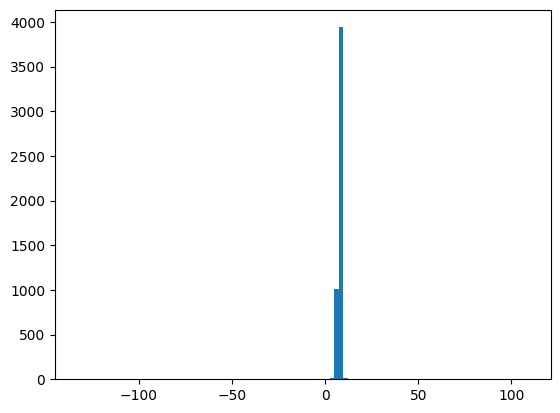

In [376]:
plt.hist(s2_data, bins=100) # Zoom in on the main peak
plt.show()

In [377]:
np.percentile(s2_data, [1, 5, 50, 95, 99])

array([6.48431666, 7.14396382, 7.6348552 , 8.249152  , 9.08906454])

In [1033]:
folder_name

'el18_18_N12_V11.68366105_20_U33.33476886'

In [1086]:
folder_name2 = 'el36_0_N12_V11.68366105_20_U33.33476886'
train_data2 = load_csv_data(folder_name2, "train_stats.csv", combine=False)

In [74]:
folder_name2 = f"el{6}_{6}_N{num_unit_cells}_V{np.round(moire_potential_strength,8)}_{moire_potential_phi}_U{np.round(interaction_energy_scale,8)}"
train_data2 = load_csv_data(folder_name2, "train_stats.csv")

In [1123]:
folder_name3 = 'Sel18_18_N12_V11.68366105_20_U33.33476886'
train_data3 = load_csv_data(folder_name3, "train_stats.csv", combine=False)

In [234]:
def calculate_blocking_error(data, max_block_size):
    """
    Calculates the standard error of the mean for different block sizes.
    """
    data = np.asarray(data)
    N = len(data)
    block_sizes = np.arange(1, max_block_size + 1)
    standard_errors = []

    for B in block_sizes:
        N_B = N // B  # Number of full blocks
        
        # We need at least 2 blocks to calculate a variance
        if N_B < 2:
            break
            
        # Truncate the data so it divides perfectly into our blocks
        truncated_data = data[:N_B * B]
        
        # Reshape into a 2D array: (Number of Blocks, Block Size)
        blocks = truncated_data.reshape((N_B, B))
        
        # Calculate the mean of each block
        block_means = np.mean(blocks, axis=1)
        
        # Calculate the variance of the block means (ddof=1 for sample variance)
        block_var = np.var(block_means, ddof=1)
        
        # Standard error of the mean for this block size
        se = np.sqrt(block_var / N_B)
        standard_errors.append(se)

    return block_sizes[:len(standard_errors)], np.array(standard_errors)

In [1097]:
window = 1000

# Calculate moving average
train_data['energy_ma'] = (
    train_data['energy']
    .rolling(window=window, min_periods=window)
    .mean()
)

In [1098]:
train_data2['energy_ma'] = (
    train_data2['energy']
    .rolling(window=window, min_periods=window)
    .mean()
)

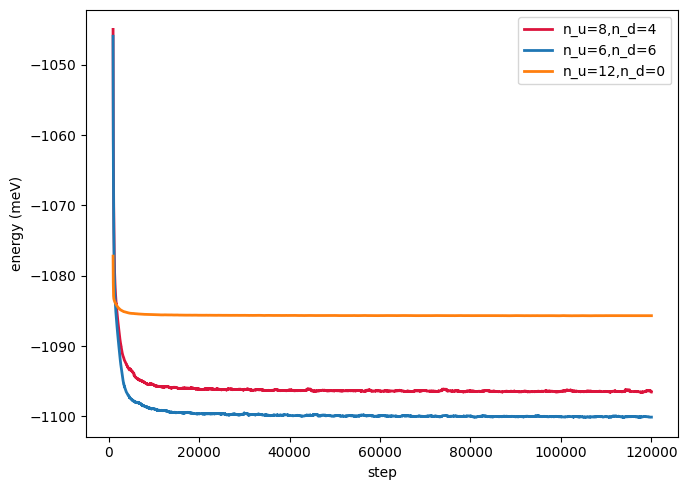

In [311]:
fig, ax = plt.subplots(1,1, figsize = (7,5))
# Moving average
ax.plot(
    train_data['step'][1000:],
    train_data['energy_ma'][1000:] * energy_scale ,
    linestyle='-', linewidth=2, color='crimson', label='n_u=8,n_d=4'
)
ax.plot(
    train_data2['step'][1000:],
    train_data2['energy_ma'][1000:] * energy_scale ,
    linestyle='-', linewidth=2, label='n_u=6,n_d=6'
)
ax.plot(
    train_data3['step'][1000:],
    train_data3['energy_ma'][1000:] * energy_scale ,
    linestyle='-', linewidth=2, label='n_u=12,n_d=0'
)
ax.set_xlabel("step")
ax.set_ylabel("energy (meV)")
ax.legend()
plt.tight_layout()
#plt.savefig('energy_av7.pdf', bbox_inches='tight')
plt.show()

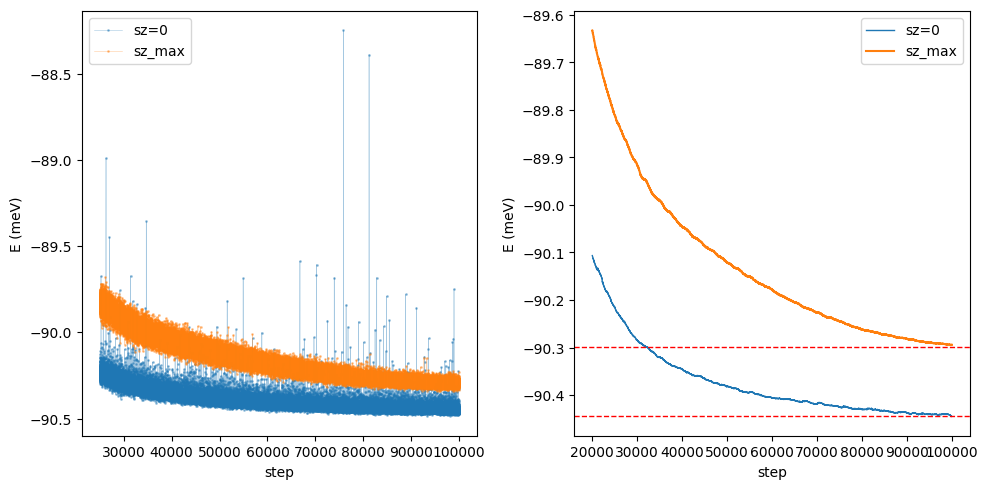

In [1141]:
fig, ax = plt.subplots(1,2, figsize = (10,5))
# Moving average

ax[0].plot(
    train_data['step'][25000:],
    train_data['energy'][25000:] * energy_scale / 36  , marker='o', linestyle='-', linewidth=0.4, markersize=1, alpha=0.4, label='sz=0'
)
ax[0].plot(
    train_data2['step'][25000:],
    train_data2['energy'][25000:] * energy_scale / 36   , marker='o', linestyle='-', linewidth=0.4, markersize=1, alpha=0.4, label='sz_max'
)
#ax[0].plot(
 #   train_data3['step'][0:],
  #  train_data3['energy'][0:] * energy_scale / 12   , marker='o', linestyle='-', linewidth=0.4, markersize=1, alpha=0.4, label='sz=0'
#)
ax[1].plot(
    train_data['step'][20000:],
    train_data['energy_ma'][20000:] * energy_scale / 36, linestyle='-', linewidth=1.0, label='sz=0'
)
ax[1].plot(
    train_data2['step'][20000:],
    train_data2['energy_ma'][20000:] * energy_scale / 36, linestyle='-', label='sz_max'
)
plt.axhline(y=-90.298, color='red', linestyle='--', linewidth=1)
plt.axhline(y=-90.445, color='red', linestyle='--', linewidth=1)
ax[0].set_xlabel("step")
ax[0].set_ylabel("E (meV)")
ax[1].set_xlabel("step")
ax[1].set_ylabel("E (meV)")
#plt.ylim(-3260/energy_scale, -3225/energy_scale)
ax[0].legend()
ax[1].legend()
plt.tight_layout()
#plt.savefig('energy_N36_sz0vs_sz_max.pdf', bbox_inches='tight')
plt.show()

In [749]:
BATCH_SIZE = 2048
NELEC      = 36

raw = pd.read_csv(os.path.join(folder_name, "train_stats.csv"))
df  = raw[np.isfinite(raw.energy) & np.isfinite(raw.ewvar)].reset_index(drop=True)
print(f"{len(df)} finite rows of {len(raw)}")

E, mu, V = (df[c].to_numpy(float) for c in ("energy", "ewmean", "ewvar"))

# delta_t = x_t - mu_{t-1}; solve V_t = (1-a)(V_{t-1} + a*delta_t^2) for a.
d = E[1:] - mu[:-1]
grid = np.linspace(0.005, 0.5, 4000)
resid = [np.sqrt(np.mean(((1-a)*(V[:-1] + a*d**2) - V[1:])**2)) for a in grid]
ALPHA = grid[int(np.argmin(resid))]
print(f"recovered alpha = {ALPHA:.4f}   rms residual = {min(resid):.3e}")

100000 finite rows of 100000
recovered alpha = 0.0999   rms residual = 4.423e-02


In [750]:
d_mean = np.full(len(df), np.nan)          # signed, from the mean column
d_mean[1:] = E[1:] - mu[:-1]

d_var = np.full(len(df), np.nan)           # magnitude, from the variance column
d_var[1:] = np.sqrt(np.maximum(V[1:]/(1-ALPHA) - V[:-1], 0.0) / ALPHA)

ok = np.isfinite(d_mean) & np.isfinite(d_var)
rel = np.abs(np.abs(d_mean[ok]) - d_var[ok]) / (np.median(np.abs(d_mean[ok])) + 1e-30)
print(f"median relative mismatch between the two paths: {np.median(rel):.2e}")

median relative mismatch between the two paths: 7.84e-04


In [751]:
WINDOW = 501
s   = pd.Series(d_mean)
med = s.rolling(WINDOW, center=True, min_periods=WINDOW//4).median()
mad = (s-med).abs().rolling(WINDOW, center=True, min_periods=WINDOW//4).median()
z   = ((s - med) / (1.4826*mad + 1e-30)).to_numpy()   # rolling median/MAD z-score

def hill(x, k_frac=0.02):
    a = np.sort(np.abs(x[np.isfinite(x)]))[::-1]
    k = max(10, int(k_frac*len(a)))
    return 1.0/np.mean(np.log(a[:k]/a[k])) if k < len(a) and a[k] > 0 else np.nan

sig = 1.4826*np.nanmedian(np.abs(d_mean))
print(f"robust sigma(delta)  : {sig:.3f} E_h   ({sig/NELEC:.4f} per electron)")
print(f"max |delta|          : {np.nanmax(np.abs(d_mean)):.3f} E_h")
print(f"implied worst E_out  : {np.nanmax(np.abs(d_mean))*BATCH_SIZE:.3e} E_h")
print(f"Hill tail index      : {hill(d_mean):.2f}   (<~3 => heavy tail)")

robust sigma(delta)  : 1.011 E_h   (0.0281 per electron)
max |delta|          : 527.434 E_h
implied worst E_out  : 1.080e+06 E_h
Hill tail index      : 1.47   (<~3 => heavy tail)


In [752]:
THRESH = 6.0
idx = np.where(np.isfinite(z) & (np.abs(z) > THRESH))[0]
print(f"{idx.size} events with |z|>{THRESH}  ({100*idx.size/len(df):.3f}% of steps)")

pd.DataFrame({
    "step":    df.step.values[idx],
    "delta":   d_mean[idx],
    "z":       z[idx],
    "E_out":   mu[idx] + d_mean[idx]*BATCH_SIZE,
    "pmove":   df.pmove.values[idx],
}).reindex(np.argsort(-np.abs(z[idx]))[:20]).round(3)

591 events with |z|>6.0  (0.591% of steps)


,step,delta,z,E_out,pmove
361,75841,89.003,129.725,178594.292,0.521
65,21178,197.202,118.740,400208.846,0.515
416,81200,82.988,113.147,166276.048,0.521
77,23142,107.040,71.280,215546.480,0.517
294,66772,33.414,44.877,64744.026,0.519
434,82803,30.656,43.108,59093.217,0.523
319,70273,32.893,40.785,63676.263,0.519
582,98923,28.416,40.582,54506.459,0.518
343,73928,30.103,39.987,57961.135,0.519
449,84869,26.339,39.715,50252.469,0.523


Spearman(rate, step) = +0.902  (p=6e-05)  RISING


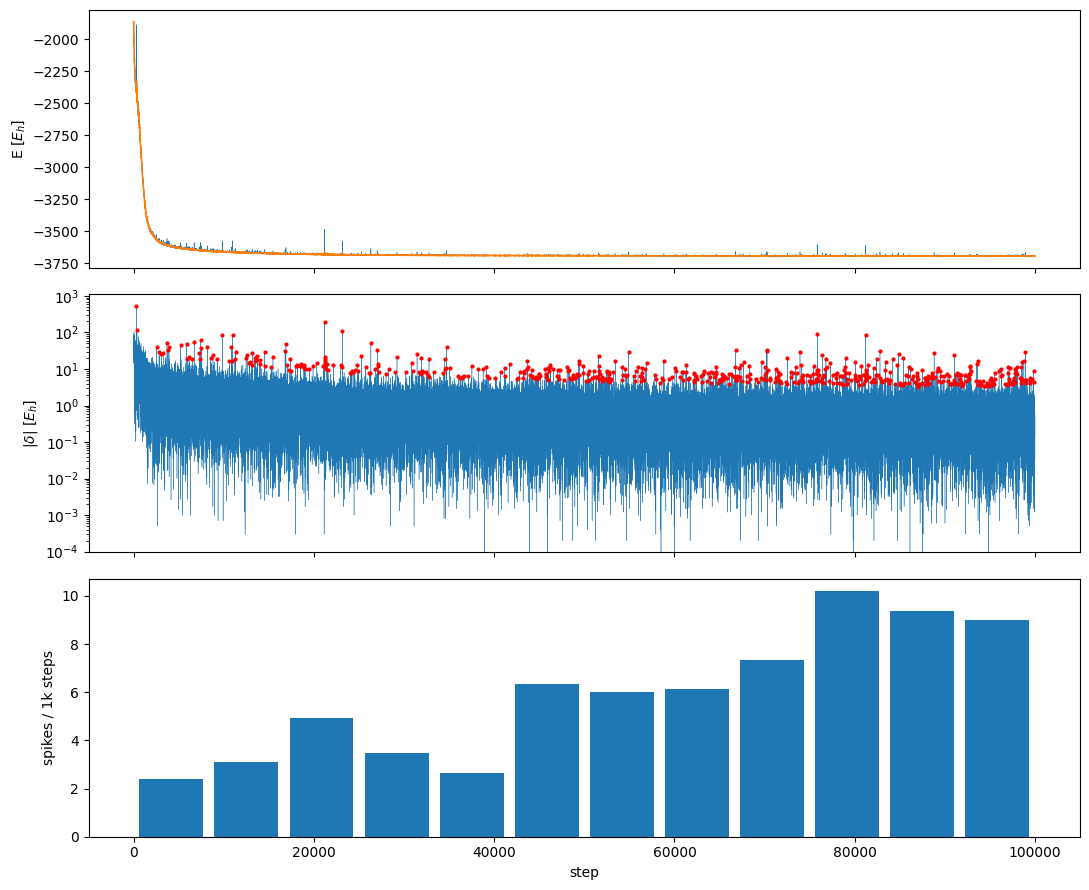

In [753]:
NB = 12
edges = np.linspace(df.step.min(), df.step.max(), NB+1)
cnt, _ = np.histogram(df.step.values[idx], bins=edges)
tot, _ = np.histogram(df.step.values,      bins=edges)
rate = 1000*cnt/np.maximum(tot, 1)

from scipy.stats import spearmanr
mid = 0.5*(edges[:-1]+edges[1:])
rho, p = spearmanr(mid[tot>0], rate[tot>0])
print(f"Spearman(rate, step) = {rho:+.3f}  (p={p:.3g})  "
      f"{'RISING' if rho>0.5 else 'flat/falling'}")

fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
ax[0].plot(df.step, E, lw=.4); ax[0].plot(df.step, mu, lw=1.2)
ax[0].set_ylabel("E [$E_h$]")
ax[1].semilogy(df.step, np.abs(d_mean), lw=.3)
ax[1].semilogy(df.step.values[idx], np.abs(d_mean[idx]), "r.", ms=4)
ax[1].set_ylabel(r"$|\delta|$ [$E_h$]")
ax[2].bar(mid, rate, width=np.diff(edges)*.85)
ax[2].set_ylabel("spikes / 1k steps"); ax[2].set_xlabel("step")
plt.tight_layout()

decay over steps 20k-81k: 0.402x  (improving)


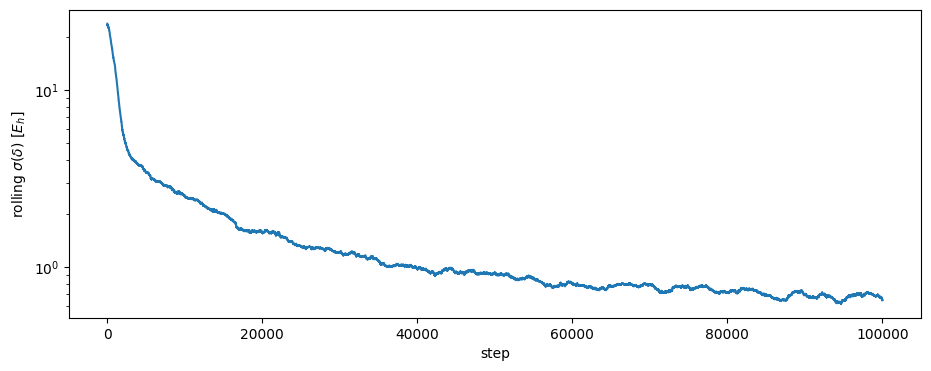

In [754]:
w = 2001
sig_t = 1.4826*pd.Series(np.abs(d_mean)).rolling(w, center=True, min_periods=500).median()

fig, ax = plt.subplots(figsize=(11,4))
ax.semilogy(df.step, sig_t); ax.set_ylabel(r"rolling $\sigma(\delta)$ [$E_h$]")
ax.set_xlabel("step")

m = np.isfinite(sig_t) & (df.step > 2000)
sl, ic = np.polyfit(df.step[m], np.log(sig_t[m]), 1)
print(f"decay over steps 20k-81k: {np.exp(sl*61000):.3f}x  "
      f"({'improving' if sl < 0 else 'FLAT OR WORSENING'})")

In [756]:
seg = lambda a, b: np.nanmedian(mu[(df.step >= a) & (df.step < b)])
for a, b in [(20000,25000), (40000,45000), (60000,65000), (76000,81000), (85000,90000), (95000,99999)]:
    print(f"{a//1000}-{b//1000}k:  E = {seg(a,b):10.2f}   E/N = {seg(a,b)/36:8.4f}")

20-25k:  E =   -3682.62   E/N = -102.2950
40-45k:  E =   -3689.90   E/N = -102.4972
60-65k:  E =   -3691.96   E/N = -102.5546
76-81k:  E =   -3692.79   E/N = -102.5776
85-90k:  E =   -3693.10   E/N = -102.5860
95-99k:  E =   -3693.30   E/N = -102.5917


In [442]:
import glob
f = sorted(glob.glob(os.path.join(folder_name,"qmcjax_ckpt_*.npz"), recursive=True))[0]
z = np.load(f, allow_pickle=True)
print(f, "\nkeys:", list(z.keys()))
for k in z.keys():
    a = z[k]
    print(f"  {k:12s} shape={a.shape} dtype={a.dtype}")

el18_18_N12_V6.56171054_45_U18.89726126/qmcjax_ckpt_020149.npz 
keys: ['t', 'data', 'params', 'opt_state', 'mcmc_width']
  t            shape=() dtype=int64
  data         shape=() dtype=object
  params       shape=() dtype=object
  opt_state    shape=() dtype=object
  mcmc_width   shape=(2,) dtype=float32


In [470]:
ok = cp[np.isfinite(cp.l2)].reset_index(drop=True)
print(f"{len(ok)} finite of {len(cp)} checkpoints; "
      f"non-finite at steps {cp.step[~np.isfinite(cp.l2)].tolist()}")

if len(ok) > 1:
    g = ok.l2.iloc[-1] / ok.l2.iloc[0]
    span = ok.step.iloc[-1] - ok.step.iloc[0]
    print(f"|p| growth over {ok.step.iloc[0]}-{ok.step.iloc[-1]} "
          f"({span} steps): {g:.3f}x")
    print(f"  per 60k steps: {g**(60000/span):.3f}x   vs variance 1.956x")
print(ok[["step","l2","rms","max_abs"]].to_string(index=False,
      float_format=lambda v: f"{v:.4f}"))

252 finite of 253 checkpoints; non-finite at steps [81435]
|p| growth over 20149-81172 (61023 steps): 1.179x
  per 60k steps: 1.176x   vs variance 1.956x
 step      l2    rms  max_abs
20149 81.3887 0.1263   3.4662
20389 81.3979 0.1263   3.4663
20626 81.3885 0.1263   3.4657
20868 81.3754 0.1263   3.4658
21107 81.3850 0.1263   3.4656
21347 81.3967 0.1263   3.4661
21588 81.4428 0.1264   3.4656
21828 81.4835 0.1264   3.4660
22070 81.5351 0.1265   3.4659
22310 81.6317 0.1267   3.4659
22553 82.2553 0.1276   3.4657
22792 82.4188 0.1279   3.4657
23034 82.4604 0.1279   3.4657
23273 82.4846 0.1280   3.4657
23514 82.4781 0.1280   3.4657
23754 82.4925 0.1280   3.4657
23996 82.5236 0.1280   3.4657
24235 82.7755 0.1284   3.4656
24476 83.0533 0.1289   3.4656
24715 83.1830 0.1291   3.4656
24955 83.2321 0.1291   3.4654
25194 83.2509 0.1292   3.4653
25435 83.2684 0.1292   3.4654
25673 83.2713 0.1292   3.4650
25912 83.2879 0.1292   3.4648
26151 83.3315 0.1293   3.4637
26392 83.6382 0.1298   3.4637
26631 

In [447]:
def named_leaves(obj, path="", out=None):
    out = [] if out is None else out
    if isinstance(obj, np.ndarray):
        if obj.dtype == object:
            named_leaves(obj.item() if obj.ndim == 0 else list(obj.ravel()), path, out)
        elif np.issubdtype(obj.dtype, np.number):
            out.append((path or "<root>", np.asarray(obj)))
    elif isinstance(obj, Mapping):
        for k in sorted(obj.keys(), key=str):
            named_leaves(obj[k], f"{path}/{k}", out)
    elif isinstance(obj, Sequence) and not isinstance(obj, (str, bytes)):
        for i, v in enumerate(obj):
            named_leaves(v, f"{path}[{i}]", out)
    elif obj is not None and not isinstance(obj, (int, float, bool, str, np.generic)):
        import jax
        for kp, l in jax.tree_util.tree_flatten_with_path(obj)[0]:
            named_leaves(np.asarray(l), path + jax.tree_util.keystr(kp), out)
    return out

bad = cp.step[~np.isfinite(cp.l2)].iloc[0]
f = [p for p in glob.glob(CKPT_GLOB)
     if int(np.load(p, allow_pickle=True)["t"]) == bad][0]
z = np.load(f, allow_pickle=True)
pz = z["params"]; pz = pz.item() if pz.dtype == object else pz

tot = nbad = 0
for name, a in named_leaves(pz):
    a = deshard(a)
    n = (~np.isfinite(a)).sum()
    tot += a.size; nbad += n
    if n:
        print(f"  {name:55s} {str(a.shape):18s} {n:>8}/{a.size} non-finite")
print(f"\n{nbad}/{tot} ({100*nbad/tot:.2f}%) of parameters non-finite")

  /jastrow/ee_anti                                        (1,)                      1/1 non-finite
  /jastrow/ee_par                                         (1,)                      1/1 non-finite
  /layers/attention[0]/attn_output                        (128, 128)            16384/16384 non-finite
  /layers/attention[0]/k_w                                (128, 128)            16384/16384 non-finite
  /layers/attention[0]/q_w                                (128, 128)            16384/16384 non-finite
  /layers/attention[0]/v_w                                (128, 128)            16384/16384 non-finite
  /layers/attention[1]/attn_output                        (128, 128)            16384/16384 non-finite
  /layers/attention[1]/k_w                                (128, 128)            16384/16384 non-finite
  /layers/attention[1]/q_w                                (128, 128)            16384/16384 non-finite
  /layers/attention[1]/v_w                                (128, 128)            1

In [448]:
os_ = z["opt_state"]; os_ = os_.item() if os_.dtype == object else os_
tot = nbad = 0
for name, a in named_leaves(os_):
    a = deshard(a); n = (~np.isfinite(a)).sum(); tot += a.size; nbad += n
    if n: print(f"  {name:60s} {n:>9}/{a.size}")
print(f"{nbad}/{tot} non-finite" if tot else f"no leaves: {type(os_)}")

  [<flat index 0>]['jastrow']['ee_anti']                               1/1
  [<flat index 0>]['jastrow']['ee_par']                                1/1
  [<flat index 0>]['layers']['attention'][0]['attn_output']        16384/16384
  [<flat index 0>]['layers']['attention'][0]['k_w']                16384/16384
  [<flat index 0>]['layers']['attention'][0]['q_w']                16384/16384
  [<flat index 0>]['layers']['attention'][0]['v_w']                16384/16384
  [<flat index 0>]['layers']['attention'][1]['attn_output']        16384/16384
  [<flat index 0>]['layers']['attention'][1]['k_w']                16384/16384
  [<flat index 0>]['layers']['attention'][1]['q_w']                16384/16384
  [<flat index 0>]['layers']['attention'][1]['v_w']                16384/16384
  [<flat index 0>]['layers']['attention'][2]['attn_output']        16384/16384
  [<flat index 0>]['layers']['attention'][2]['k_w']                16384/16384
  [<flat index 0>]['layers']['attention'][2]['q_w']         

In [449]:
print(f"{'leaf':70s} {'shape':20s} {'finite?':>8}")
for name, a in named_leaves(os_):
    a = deshard(a)
    fin = np.isfinite(a).all()
    if a.size > 1000 or not fin:
        print(f"  {name[:68]:70s} {str(a.shape):20s} {str(bool(fin)):>8}")

leaf                                                                   shape                 finite?
  [<flat index 0>]['jastrow']['ee_anti']                                 (1,)                    False
  [<flat index 0>]['jastrow']['ee_par']                                  (1,)                    False
  [<flat index 0>]['layers']['attention'][0]['attn_output']              (128, 128)              False
  [<flat index 0>]['layers']['attention'][0]['k_w']                      (128, 128)              False
  [<flat index 0>]['layers']['attention'][0]['q_w']                      (128, 128)              False
  [<flat index 0>]['layers']['attention'][0]['v_w']                      (128, 128)              False
  [<flat index 0>]['layers']['attention'][1]['attn_output']              (128, 128)              False
  [<flat index 0>]['layers']['attention'][1]['k_w']                      (128, 128)              False
  [<flat index 0>]['layers']['attention'][1]['q_w']                      (1

In [450]:
def state_summary(step):
    f = [p for p in glob.glob(CKPT_GLOB)
         if int(np.load(p, allow_pickle=True)["t"]) == step][0]
    zz = np.load(f, allow_pickle=True)
    s = zz["opt_state"]; s = s.item() if s.dtype == object else s
    return {n: deshard(a) for n, a in named_leaves(s)}

g, b = state_summary(81172), state_summary(81435)
for n in g:
    ag, ab = g[n], b.get(n)
    if ag.size < 1000: continue
    fin = np.isfinite(ab).all() if ab is not None else None
    print(f"  {n[:60]:62s} |g|={np.linalg.norm(ag):11.3e}  bad_finite={fin}")

  [<flat index 0>]['layers']['attention'][0]['attn_output']      |g|=  1.244e-02  bad_finite=False
  [<flat index 0>]['layers']['attention'][0]['k_w']              |g|=  4.306e-04  bad_finite=False
  [<flat index 0>]['layers']['attention'][0]['q_w']              |g|=  1.998e-04  bad_finite=False
  [<flat index 0>]['layers']['attention'][0]['v_w']              |g|=  1.128e-03  bad_finite=False
  [<flat index 0>]['layers']['attention'][1]['attn_output']      |g|=  1.972e-02  bad_finite=False
  [<flat index 0>]['layers']['attention'][1]['k_w']              |g|=  1.328e-02  bad_finite=False
  [<flat index 0>]['layers']['attention'][1]['q_w']              |g|=  1.500e-02  bad_finite=False
  [<flat index 0>]['layers']['attention'][1]['v_w']              |g|=  2.606e-02  bad_finite=False
  [<flat index 0>]['layers']['attention'][2]['attn_output']      |g|=  2.829e-03  bad_finite=False
  [<flat index 0>]['layers']['attention'][2]['k_w']              |g|=  4.409e-03  bad_finite=False
  [<flat i

In [165]:
r_target = np.array([1.5, 0.0]) # Replace with your actual target coordinates

pinned_relative_positions = []
pinned_spin_weights = []

# --- 2. Extract Pinned Vectors ---
for cntc in range(len(positions_batch)):
    config_pos = positions_batch[cntc]   # Shape: (12, 2)
    config_spin = spins_batch[cntc]      # Shape: (12,)
    
    # Calculate the physical distance from all 12 electrons to the target site
    distances = np.linalg.norm(config_pos - r_target, axis=1)
    
    # Identify the index of the electron currently sitting at the target site
    ref_idx = np.argmin(distances)
    
    # Lock in the exact position and spin of our anchor electron
    ref_pos = config_pos[ref_idx]
    ref_spin = config_spin[ref_idx]
    
    # Calculate relative vectors and spin weights for the other 11 electrons
    for j in range(len(config_pos)):
        if j == ref_idx:
            continue  # Skip the self-interaction at dr = 0
            
        # Vector pointing FROM the anchor TO electron j
        dr = config_pos[j] - ref_pos
        pinned_relative_positions.append(dr.tolist())
        
        # Spin weight: +1 if parallel, -1 if anti-parallel
        weight = ref_spin * config_spin[j]
        pinned_spin_weights.append(weight)

# --- 3. Apply Periodic Boundary Conditions ---
pinned_relative_positions = lattices.send_positions_to_first_unit_cell(
    pinned_relative_positions, lat_vec, rec
)

# Convert to arrays for the Fourier transform script
dr_array = np.array(pinned_relative_positions)
weights = np.array(pinned_spin_weights)

In [166]:
# Convert your lists to numpy arrays for fast vector operations
#dr_array = np.array(relative_positions)  # Shape: (N_pairs, 2)
#weights = np.array(spin_weights)         # Shape: (N_pairs,)

# Total number of Monte Carlo snapshots (for proper normalization)
M = len(positions_batch) 

# --- 2. Setup the Grid ---
N_grid = 128  # Power of 2 for fast FFT
G_max = np.linalg.norm(8*b1)    # The cutoff you found earlier

# Use your reciprocal lattice vectors b1 and b2
n1_range = np.fft.fftfreq(N_grid) * N_grid
n2_range = np.fft.fftfreq(N_grid) * N_grid

S_G = np.zeros((N_grid, N_grid), dtype=complex)

# --- 3. Fourier Accumulation ---
for i, n1 in enumerate(n1_range):
    for j, n2 in enumerate(n2_range):
        G_vec = n1 * b1 + n2 * b2
        G_norm = np.linalg.norm(G_vec)
        
        if G_norm <= G_max:
            # G dot dr for all pairs at once
            phases = np.dot(dr_array, G_vec) 
            
            # Sum the weighted cosines and multiply by 2 for the (i>j) pairs
            # Divide by M to get the average correlation per snapshot
            S_G[i, j] = np.sum(weights * np.exp(-1j * phases)) / M

# --- 4. Inverse FFT to Real Space ---
# The FFT inherently expects the zero-frequency (G=0) component at index [0,0]
# which np.fft.fftfreq handles perfectly. 
S_real = np.fft.ifft2(S_G)

# The result of the cosine sum should be purely real, but we use np.real to drop 
# any microscopic floating-point imaginary dust
S_real = np.real(S_real) 

# Shift the zero-distance origin to the center of the image for plotting
S_real_shifted = np.fft.fftshift(S_real)

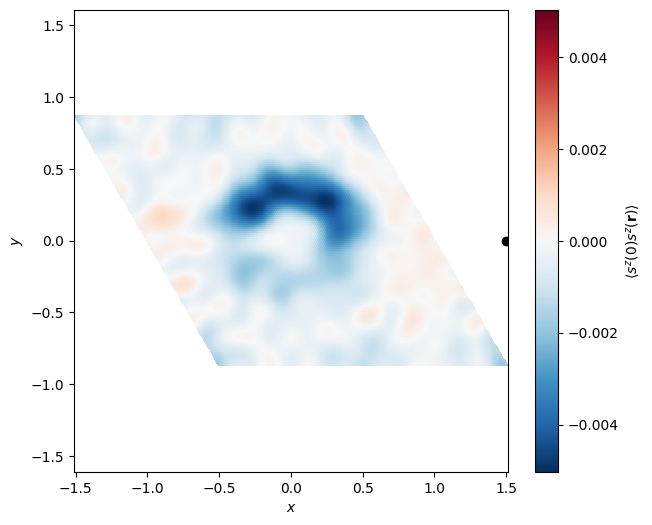

In [167]:
# --- 5. Plotting on the Physical Unit Cell ---

# 1. Create a 1D array of fractional coordinates from -0.5 to 0.5
frac = np.linspace(-0.5, 0.5, N_grid)

# 2. Create a 2D meshgrid of these fractional coordinates
F1, F2 = np.meshgrid(frac, frac)

# 3. Map the fractional grid to physical Cartesian coordinates
# X = f1 * a1_x + f2 * a2_x
# Y = f1 * a1_y + f2 * a2_y
X_grid = F1 * a1[0] + F2 * a2[0]
Y_grid = F1 * a1[1] + F2 * a2[1]

# 4. Plot using pcolormesh (which respects non-orthogonal grids)
plt.figure(figsize=(7, 6))

vmax = 12*np.max(np.abs(S_real_shifted))

# pcolormesh wraps the colored array over the custom X and Y coordinates
plt.pcolormesh(X_grid, Y_grid, 12*S_real_shifted, shading='auto', 
               cmap='RdBu_r', vmin=-vmax, vmax=vmax)

plt.colorbar(label='$\\langle s^z(0) s^z(\\mathbf{r}) \\rangle$')
#plt.title('Real-Space Spin Correlation (Physical Unit Cell)')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.scatter(r_target[0], r_target[1], color = 'black')
# This is critical to ensure the angles of your parallelogram are not distorted 
# by the window size
plt.axis('equal') 
plt.savefig("phi20_aM98nm_Sz0_szsz.png", dpi=150, bbox_inches="tight")
plt.show()

In [148]:
r_target = np.array([0.0, 0.25])
pinned_relative_positions = []
pinned_charge_weights = []

# --- 2. Extract Pinned Vectors ---
for cntc in range(len(positions_batch)):
    config_pos = positions_batch[cntc]   
    
    # Calculate distance to target and find the anchor electron
    distances = np.linalg.norm(config_pos - r_target, axis=1)
    ref_idx = np.argmin(distances)
    ref_pos = config_pos[ref_idx]
    
    # Calculate relative vectors for the other 11 electrons
    for j in range(len(config_pos)):
        if j == ref_idx:
            continue  # Skip the self-interaction
            
        dr = config_pos[j] - ref_pos
        pinned_relative_positions.append(dr.tolist())
        
        # CHARGE WEIGHT: Every electron simply counts as 1
        pinned_charge_weights.append(1.0)

# --- 3. Apply Periodic Boundary Conditions ---
pinned_relative_positions = lattices.send_positions_to_first_unit_cell(
    pinned_relative_positions, lat_vec, rec
)

dr_array = np.array(pinned_relative_positions)
weights = np.array(pinned_charge_weights)

In [149]:
# --- 2. Setup the Grid ---
N_grid = 128  # Power of 2 for fast FFT
G_max = np.linalg.norm(8*b1)    # The cutoff you found earlier

# Use your reciprocal lattice vectors b1 and b2
n1_range = np.fft.fftfreq(N_grid) * N_grid
n2_range = np.fft.fftfreq(N_grid) * N_grid

S_G = np.zeros((N_grid, N_grid), dtype=complex)

# --- 3. Fourier Accumulation ---
for i, n1 in enumerate(n1_range):
    for j, n2 in enumerate(n2_range):
        G_vec = n1 * b1 + n2 * b2
        G_norm = np.linalg.norm(G_vec)
        
        if G_norm <= G_max:
            # G dot dr for all pairs at once
            phases = np.dot(dr_array, G_vec) 
            
            # Sum the weighted cosines and multiply by 2 for the (i>j) pairs
            # Divide by M to get the average correlation per snapshot
            S_G[i, j] = np.sum(weights * np.exp(-1j * phases)) / M

# --- 4. Inverse FFT to Real Space ---
# The FFT inherently expects the zero-frequency (G=0) component at index [0,0]
# which np.fft.fftfreq handles perfectly. 
S_real = np.fft.ifft2(S_G)

# The result of the cosine sum should be purely real, but we use np.real to drop 
# any microscopic floating-point imaginary dust
S_real = np.real(S_real) 

# Shift the zero-distance origin to the center of the image for plotting
S_real_shifted = np.fft.fftshift(S_real)

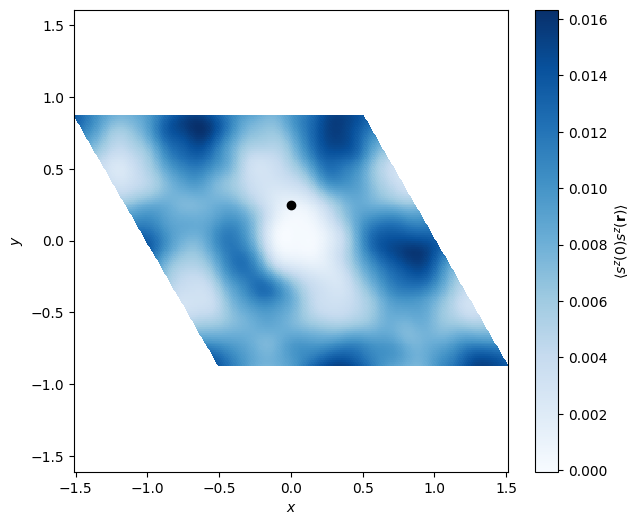

In [150]:
# --- 5. Plotting on the Physical Unit Cell ---

# 1. Create a 1D array of fractional coordinates from -0.5 to 0.5
frac = np.linspace(-0.5, 0.5, N_grid)

# 2. Create a 2D meshgrid of these fractional coordinates
F1, F2 = np.meshgrid(frac, frac)

# 3. Map the fractional grid to physical Cartesian coordinates
# X = f1 * a1_x + f2 * a2_x
# Y = f1 * a1_y + f2 * a2_y
X_grid = F1 * a1[0] + F2 * a2[0]
Y_grid = F1 * a1[1] + F2 * a2[1]

# 4. Plot using pcolormesh (which respects non-orthogonal grids)
plt.figure(figsize=(7, 6))

vmax = 12*np.max(np.abs(S_real_shifted))

# pcolormesh wraps the colored array over the custom X and Y coordinates
plt.pcolormesh(X_grid, Y_grid, 12*S_real_shifted, shading='auto', 
               cmap='Blues')

plt.colorbar(label='$\\langle s^z(0) s^z(\\mathbf{r}) \\rangle$')
#plt.title('Real-Space Spin Correlation (Physical Unit Cell)')
plt.xlabel('$x$')
plt.ylabel('$y$')
plt.scatter(r_target[0], r_target[1], color = 'black')
# This is critical to ensure the angles of your parallelogram are not distorted 
# by the window size
plt.axis('equal') 
#plt.savefig("phi20_aM98nm_Sz0_szsz.png", dpi=150, bbox_inches="tight")
plt.show()

In [110]:
45*50*1000/1000000

2.25

In [108]:
24*9

216

In [564]:
def hbar2_over_m_eff(meff: float) -> float:
 """
 Returns hbar^2 / (m_eff) in units of meV·nm².
 `meff` should be given in units of the electron mass m_e.
 """
 # Physical constants
 hbar = 1.054571817e-34 # J·s
 m_e = 9.10938356e-31 # kg
 eV = 1.602176634e-19 # J
 meV = 1e-3 * eV
 nm2 = 1e-18    # m²

 # Convert hbar^2 / (2 m_eff) to meV·nm²
 value = hbar**2 / (meff * m_e)# in J·m²
 value_meV_nm2 = value / meV / nm2 # convert to meV·nm²

 return value_meV_nm2

def coulomb_prefactor(epsilon_r: float) -> float:
 """
 Compute e^2 / (4 * pi * epsilon_0 * epsilon_r * r) at r = 1 nm,
 return result in meV units.
 """

 # Constants
 e = 1.602176634e-19  # C
 epsilon_0 = 8.854187817e-12 # F/m
 r_nm = 1e-9   # m
 J_to_meV = 1 / 1.602176634e-22# 1 J = this many meV

 # Energy in J at r = 1 nm
 energy_J = e**2 / (4 * np.pi * epsilon_0 * epsilon_r * r_nm)

 # Convert to meV
 energy_meV = energy_J * J_to_meV

 return energy_meV



def get_config(write_config_snapshot: bool = True):
  # Get default options.
  #cfg = base_config.default()
  #cfg.system.electrons = (36,0)
  #cfg.system.ndim = 2
  # A ghost atom at the origin defines one-electron coordinate system.
  # Element 'X' is a dummy nucleus with zero charge
  #cfg.system.molecule = [system.Atom("X", (0., 0.,))]
  # Pretraining is not currently implemented for systems in PBC
  #cfg.pretrain.method = None

  """ Defining the potential unit cell and the supercell """
  a0 = 9.8 #nm
  a1 = a0 * np.array([np.sqrt(3)/2,-0.5])
  #a1 = a0* np.array([1,0])
  a2 = a0 * np.array([0,1])
  Tmatrix = np.array([[2,-2], [4, 2]])
  #lattice = lattice_vecs(a1, a2, Tmatrix)
  #potential_lattice = lattice_vecs(a1, a2, np.array([[1,0], [0, 1]]))
  #kpoints = envelopes.make_kpoints(lattice, cfg.system.electrons)
  #cfg.system.pbc_lattice = lattice

  """Defining KE, potential and interaction parameters"""
  meff = 0.9
  KE_prefactor = hbar2_over_m_eff(meff)
  print(KE_prefactor)
  pot_strength = 10.3 #meV
  pot_strength = pot_strength/KE_prefactor
  pp_coffs = np .array([-2*pot_strength, -2*pot_strength, -2*pot_strength])
  pp_phases = np.array([20.0* np.pi/180, 20.0* np.pi/180, 20.0* np.pi/180])
  epsilon = 5.0
  intcoff = (coulomb_prefactor(epsilon))/KE_prefactor
  #intcoff = 10.0
  print(intcoff)
  print(pot_strength)

In [565]:
coulomb_prefactor(5.0)

287.99290943190346

In [566]:
get_config(True)

84.66627045929029
3.4015069740243
0.12165411260145803


In [573]:
interaction_energy_scale*energy_scale

29.387031832796122